## DAG-VAE: tropical SST drivers of the SH-EDJ

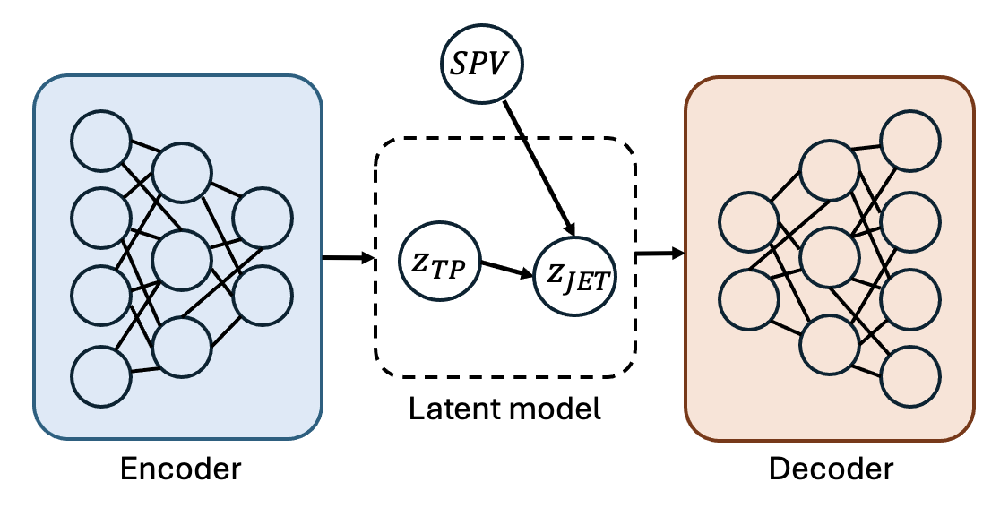

Code is split into four modules (keep them in the same folder as this notebook):

| module | contents |
|---|---|
| `preprocessing.py` | loading, seasonal means over user-chosen months, lat/lon boxes, regridding, standardising, train/test split → `DataBundle` |
| `dagvae.py` | the model: encoder, decoder, linear prediction model p(z2\|z1,u), joint VAE + losses |
| `training.py` | config defaults, multi-seed training loop, metrics, linear baseline, seed-ensemble analysis |
| `visualisation.py` | per-seed and across-seed figures, map helpers |

For every seed: fresh models (seed set *before* building), training with test-ACC tracking, a report of all
loss terms and skill scores, per-seed figures, and weights / history / latents saved to `out_dir/seed_XXX`.
Afterwards: spread across seeds, seed-ensemble prediction skill, a linear PCA-regression baseline with the
same bottleneck, and how reproducible the latents are across seeds (Hungarian-matched correlations).

In [1]:
import os
# os.environ['TF_USE_LEGACY_KERAS'] = '1'   # only needed with TensorFlow >= 2.16 (pip install tf_keras)

import copy
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import preprocessing as pp
import training as tr
import visualisation as vis

# while editing the modules, reload them without restarting the kernel:
# import importlib; [importlib.reload(m) for m in (pp, tr, vis)]

In [2]:
datapath = '../data/cesm2/'

### Preprocessing

Months, lat/lon boxes, files and weighting are all set here. Anything left out falls back to
`pp.DEFAULT_PREP` (which reproduces the September 2026 setup). Months can be ints in chronological order
(`[12, 1, 2]`) or month initials (`'DJF'`, `'SON'`, `'NDJFM'`); each season is labelled by the year of its
first month, so Oct-Nov 1850 (u) precedes DJF 1850/51 (x1, x2). Longitudes can be given as 0-360 or -180-180,
boxes may cross 0°E, and `resolution=(dlat, dlon)` interpolates onto a regular grid (None = native grid).

In [3]:
PREP = dict(
    test_frac=0.2,                 # last 20 % of seasons = test
    x1=dict(file='tos_Omon_CESM2_piControl_r1i1p1f1_gr.nc', var='tos',
            months='DJF', lat=(-20, 20), lon=(160, 285),
            resolution=None, weighting=None),
    x2=dict(file='ua850_Amon_CESM2_piControl_r1i1p1f1_gn.nc', var='ua',
            months='DJF', lat=(-65, -35), lon=None,
            resolution=None, weighting='sqrt_coslat'),
    covariates=[                   # one or more scalar covariates (box-averaged, cos-lat weighted)
        dict(name='spv', file='ua50_Amon_CESM2_piControl_r1i1p1f1_gn.nc', var='ua',
             months='ON', lat=(-65, -50), lon=None),
    ],
)

data = pp.load_and_preprocess(datapath, PREP)

x1: tos months [12, 1, 2], FieldGrid(x1: 14 lat x 45 lon, 630 active cells, weighting=None)
x2: ua months [12, 1, 2], FieldGrid(x2: 10 lat x 128 lon, 1280 active cells, weighting=sqrt_coslat)
u : spv = ua months [10, 11], lat (-65, -50), lon None (area mean)
train 799 | test 200 seasons (1-999) | x1 dim 630 | x2 dim 1280 | 1 covariate(s)


### Training


▶ training seed 0
  epoch    20  loss    923.98  val_loss    917.74  test ACC z1->x2 0.332  x2 rec 0.662
  epoch    40  loss    816.73  val_loss    789.07  test ACC z1->x2 0.318  x2 rec 0.749
  epoch    60  loss    783.28  val_loss    775.87  test ACC z1->x2 0.327  x2 rec 0.756
  epoch    80  loss    769.60  val_loss    787.89  test ACC z1->x2 0.318  x2 rec 0.753
  epoch   100  loss    758.73  val_loss    774.49  test ACC z1->x2 0.330  x2 rec 0.757

── seed 0  (5 s) ────────────────────────────────────────
                               train      test
total loss                   719.416   773.377
rec loss x1 (weighted)       204.673   205.831
rec loss x2 (weighted)       308.976   340.113
KL z1                          7.009     6.869
KL z2 | p(z2|z1,u)            13.001    13.053
pred loss x2 (weighted)      185.723   207.476
MSE x1 rec                     0.323     0.324
MSE x2 rec                     0.239     0.266
MSE x2 pred                    0.488     0.539
expl. var x1 rec 

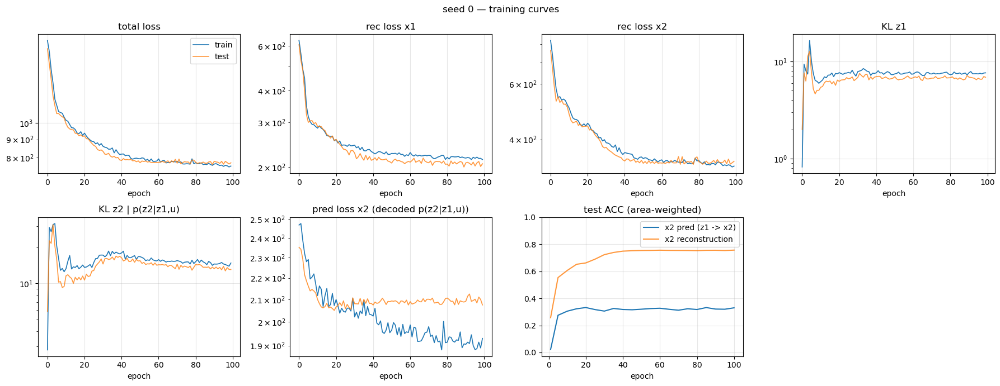

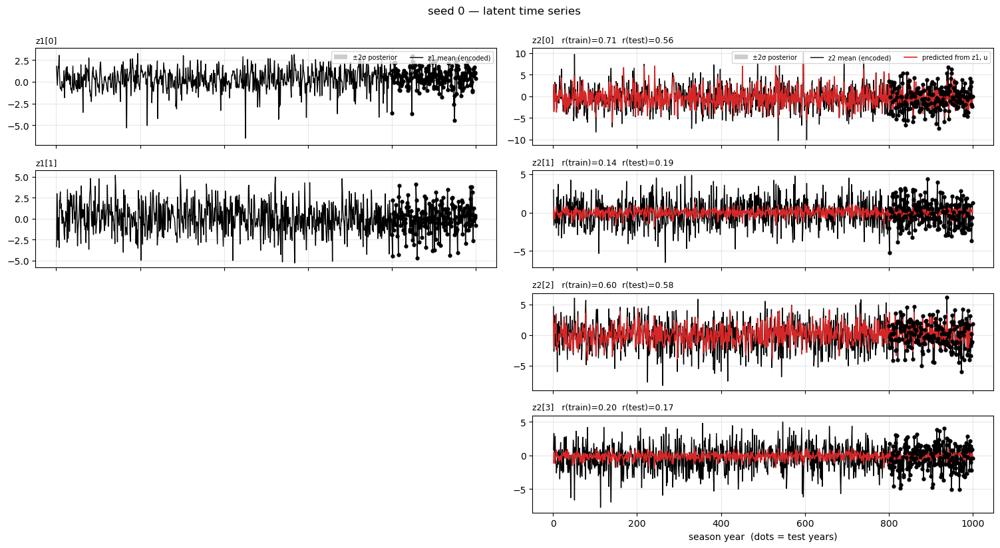

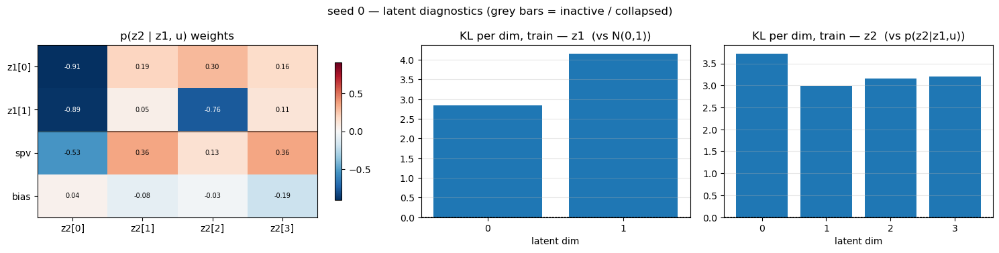

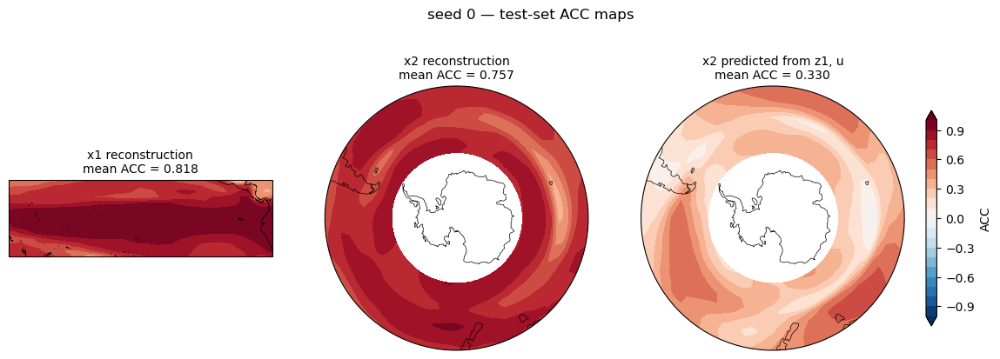

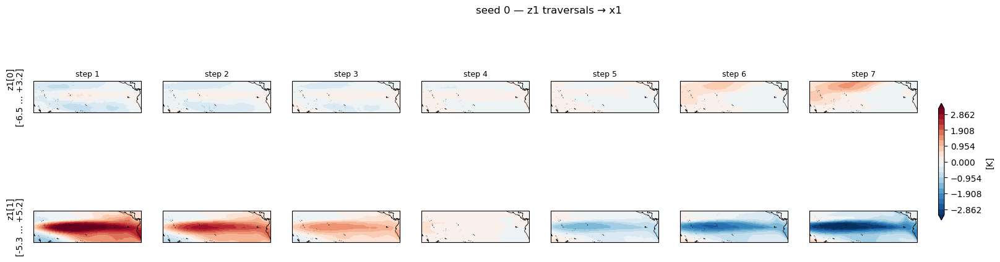

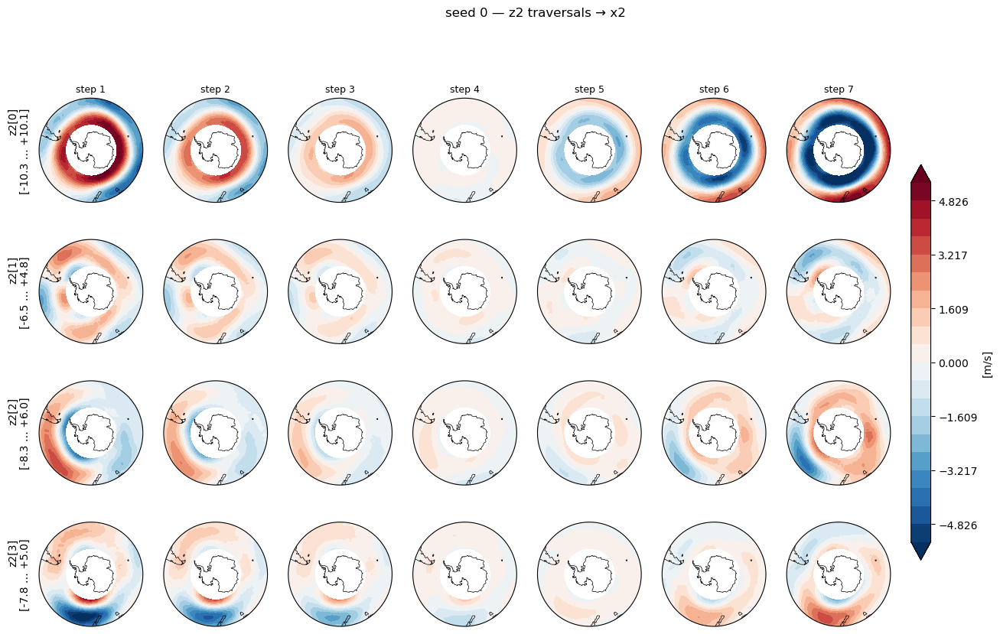

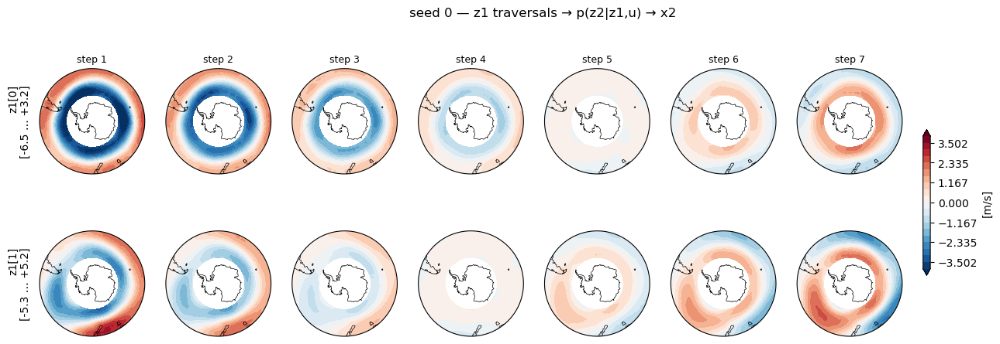

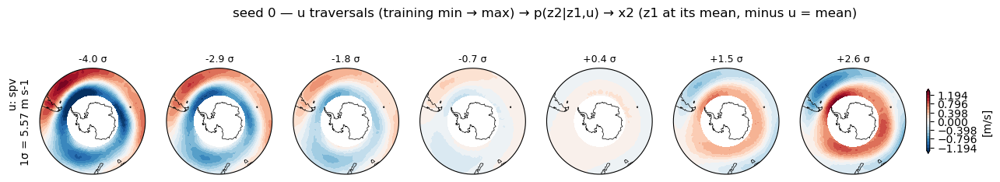


▶ training seed 1
  epoch    20  loss    936.33  val_loss    921.97  test ACC z1->x2 0.334  x2 rec 0.659
  epoch    40  loss    875.10  val_loss    843.20  test ACC z1->x2 0.318  x2 rec 0.688
  epoch    60  loss    827.96  val_loss    806.24  test ACC z1->x2 0.326  x2 rec 0.720
  epoch    80  loss    797.61  val_loss    784.09  test ACC z1->x2 0.337  x2 rec 0.740
  epoch   100  loss    779.62  val_loss    770.22  test ACC z1->x2 0.337  x2 rec 0.759

── seed 1  (5 s) ────────────────────────────────────────
                               train      test
total loss                   746.614   771.196
rec loss x1 (weighted)       197.593   199.304
rec loss x2 (weighted)       320.343   345.845
KL z1                          6.695     6.894
KL z2 | p(z2|z1,u)            13.908    13.126
pred loss x2 (weighted)      208.029   205.980
MSE x1 rec                     0.311     0.312
MSE x2 rec                     0.248     0.269
MSE x2 pred                    0.541     0.534
expl. var x1 rec 

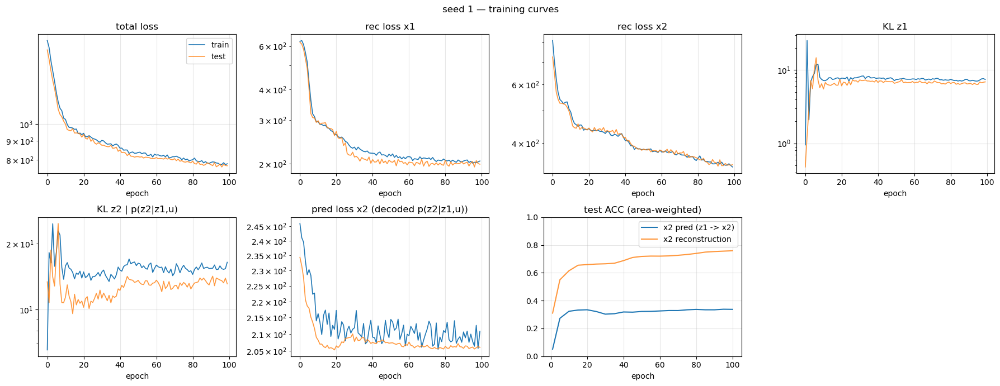

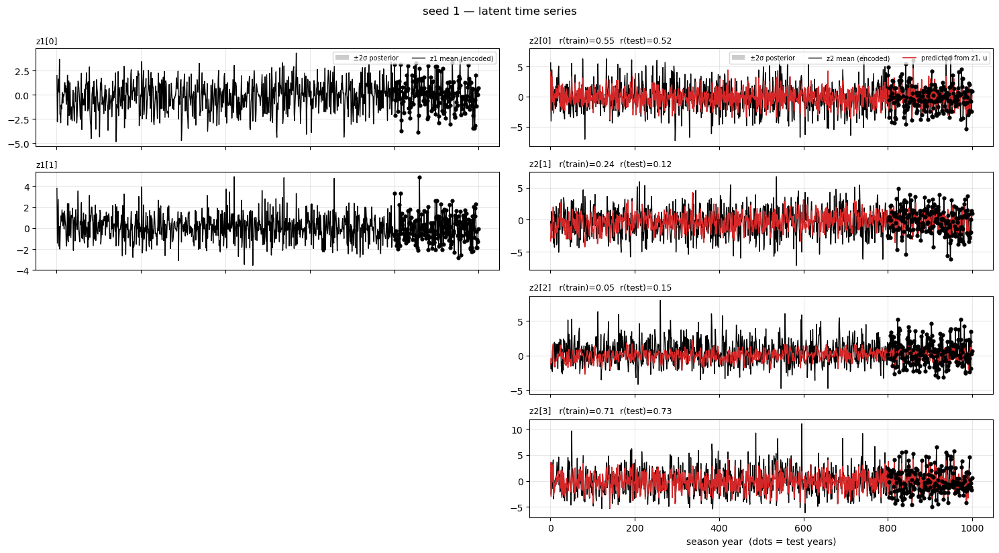

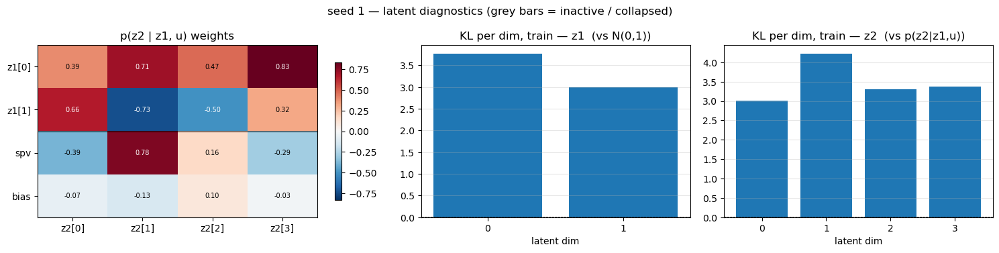

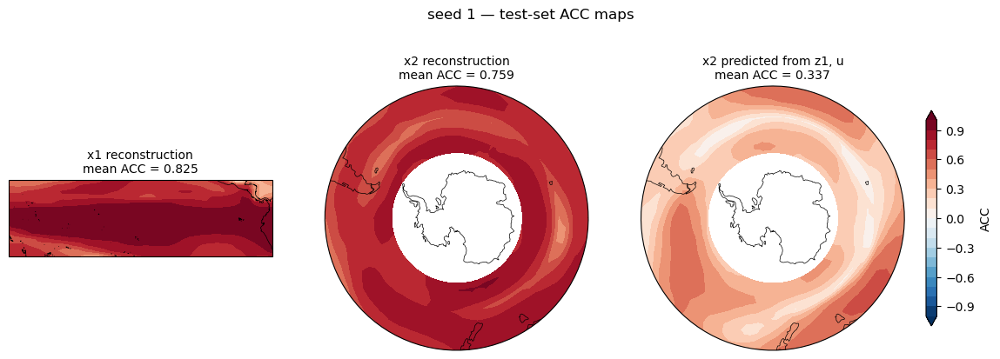

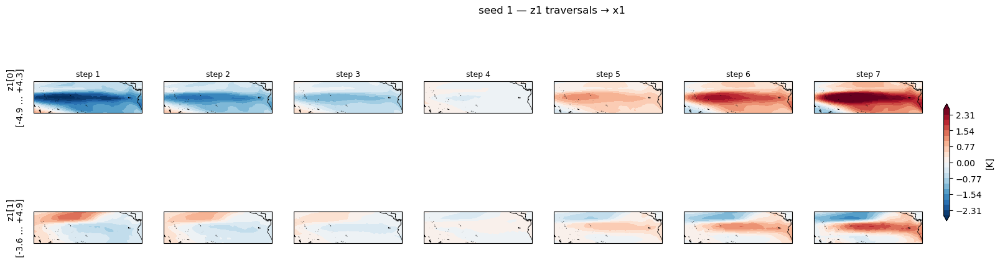

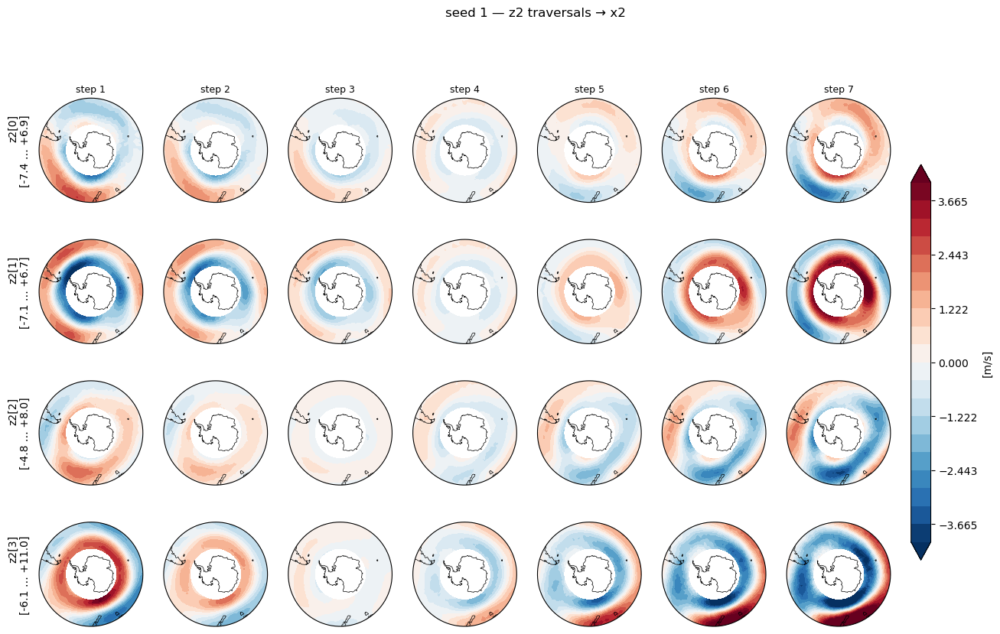

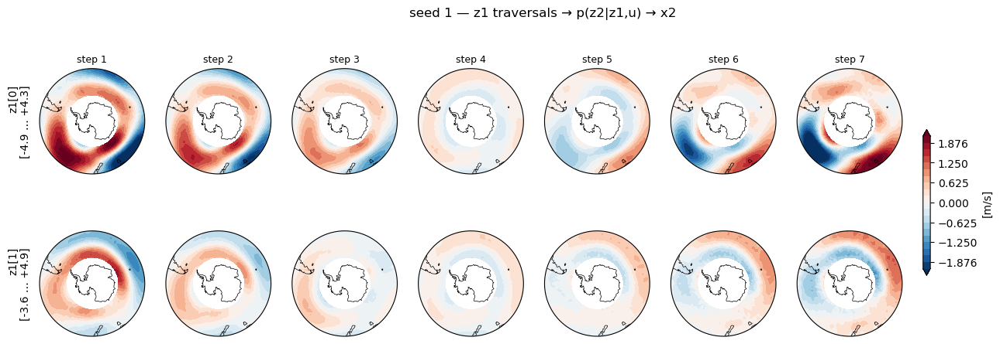

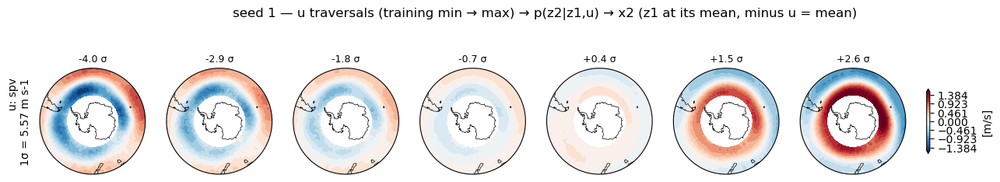


▶ training seed 2
  epoch    20  loss    959.23  val_loss    942.02  test ACC z1->x2 0.348  x2 rec 0.658
  epoch    40  loss    858.07  val_loss    852.93  test ACC z1->x2 0.322  x2 rec 0.719
  epoch    60  loss    822.57  val_loss    807.39  test ACC z1->x2 0.319  x2 rec 0.749
  epoch    80  loss    795.52  val_loss    791.73  test ACC z1->x2 0.311  x2 rec 0.758
  epoch   100  loss    759.70  val_loss    795.93  test ACC z1->x2 0.312  x2 rec 0.764

── seed 2  (5 s) ────────────────────────────────────────
                               train      test
total loss                   734.130   794.921
rec loss x1 (weighted)       220.225   223.523
rec loss x2 (weighted)       313.518   338.115
KL z1                          6.854     6.752
KL z2 | p(z2|z1,u)            12.691    13.599
pred loss x2 (weighted)      180.806   212.897
MSE x1 rec                     0.347     0.354
MSE x2 rec                     0.243     0.262
MSE x2 pred                    0.475     0.550
expl. var x1 rec 

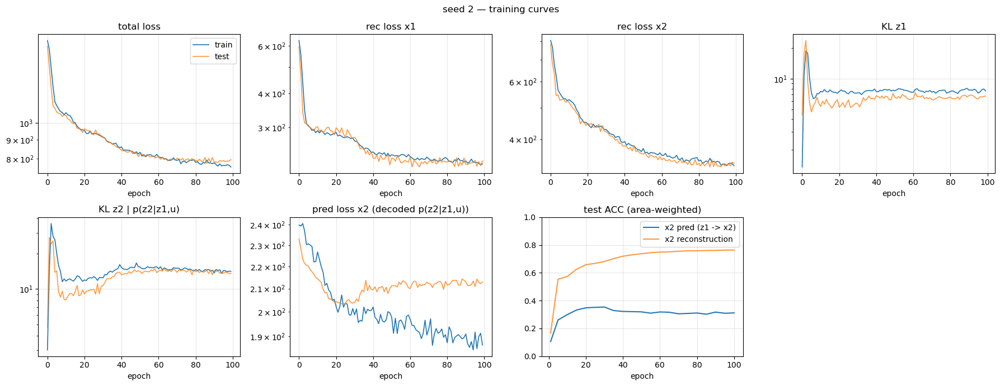

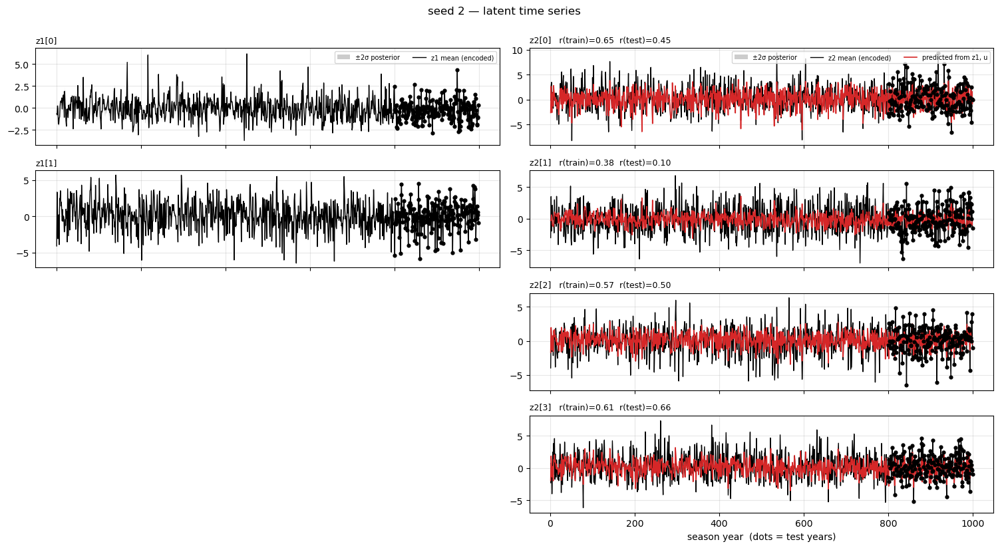

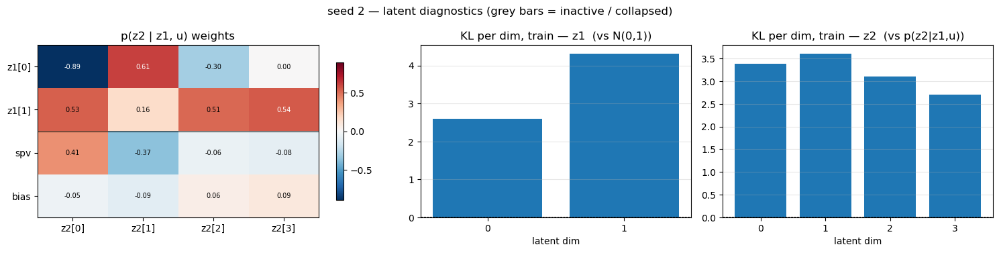

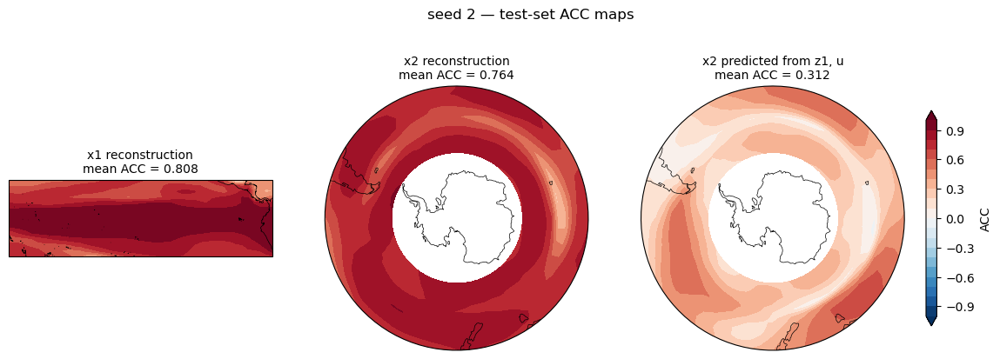

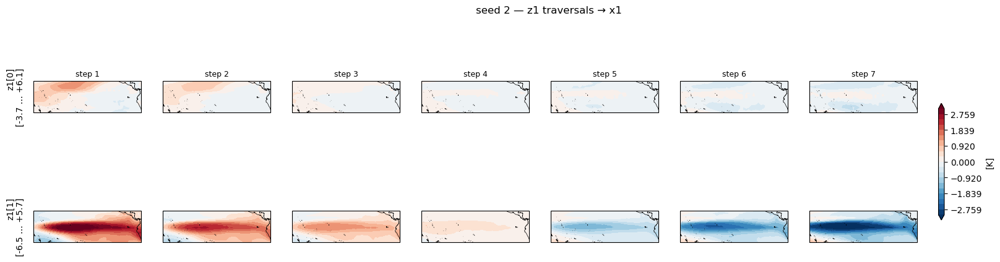

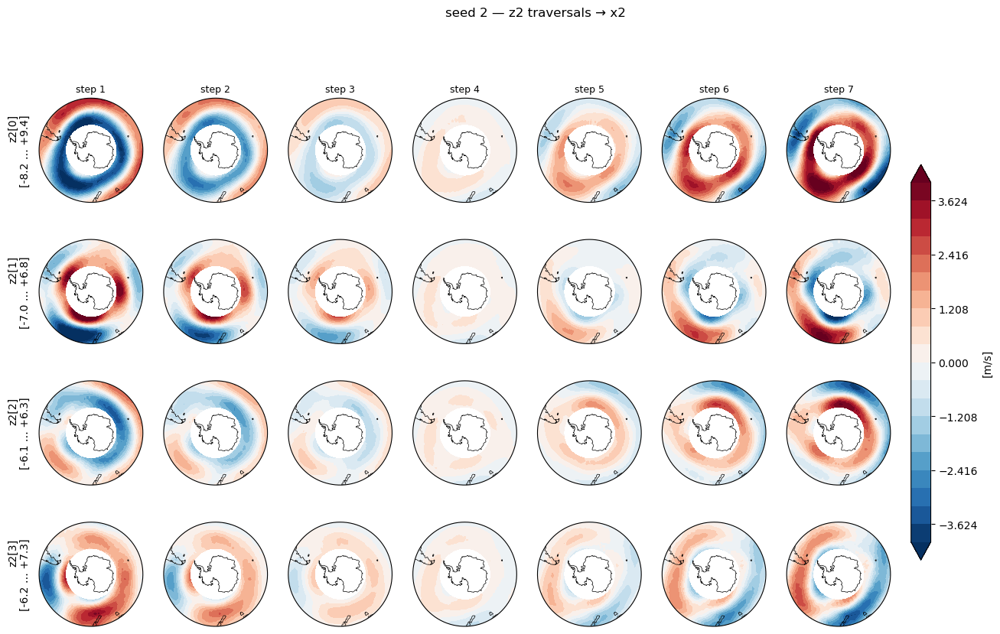

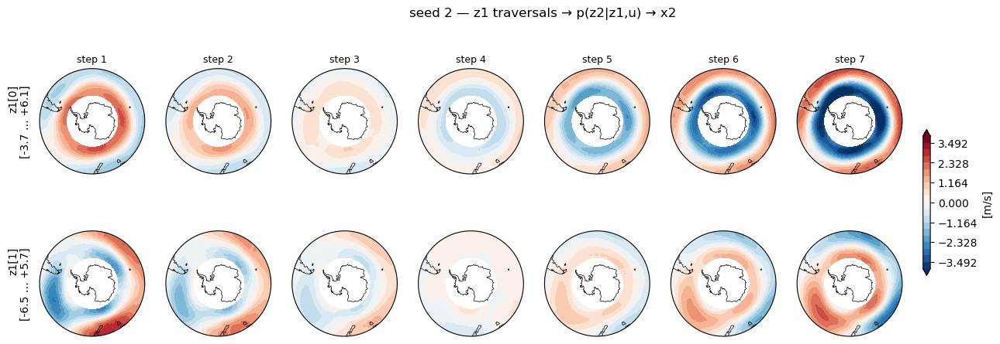

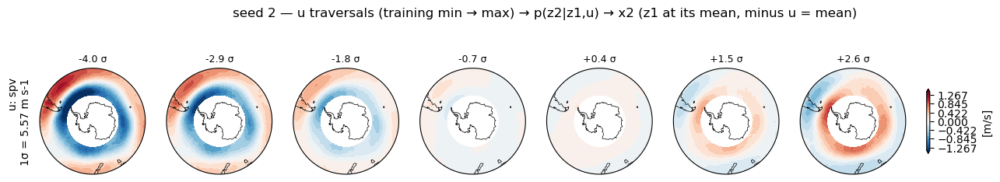


▶ training seed 3
  epoch    20  loss    902.09  val_loss    878.78  test ACC z1->x2 0.313  x2 rec 0.662
  epoch    40  loss    838.19  val_loss    832.39  test ACC z1->x2 0.305  x2 rec 0.713
  epoch    60  loss    809.97  val_loss    798.18  test ACC z1->x2 0.308  x2 rec 0.728
  epoch    80  loss    784.40  val_loss    777.16  test ACC z1->x2 0.303  x2 rec 0.759
  epoch   100  loss    762.80  val_loss    769.50  test ACC z1->x2 0.306  x2 rec 0.763

── seed 3  (5 s) ────────────────────────────────────────
                               train      test
total loss                   743.632   769.745
rec loss x1 (weighted)       204.431   206.874
rec loss x2 (weighted)       308.638   331.052
KL z1                          6.379     6.653
KL z2 | p(z2|z1,u)            13.963    13.811
pred loss x2 (weighted)      210.183   211.315
MSE x1 rec                     0.322     0.324
MSE x2 rec                     0.238     0.257
MSE x2 pred                    0.545     0.550
expl. var x1 rec 

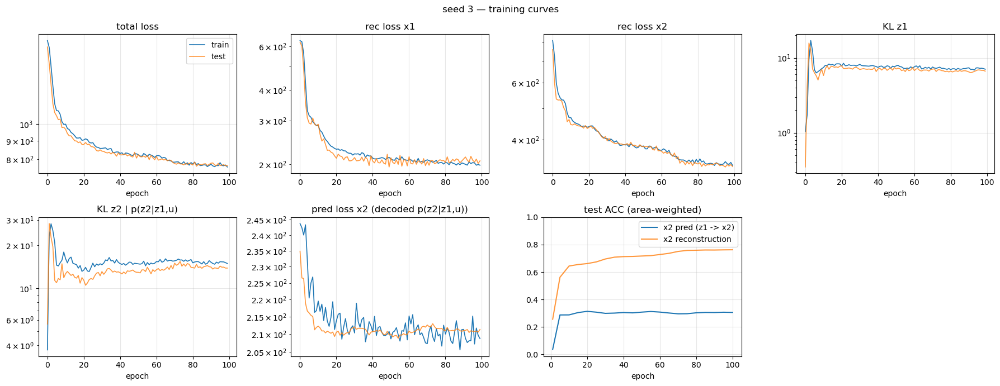

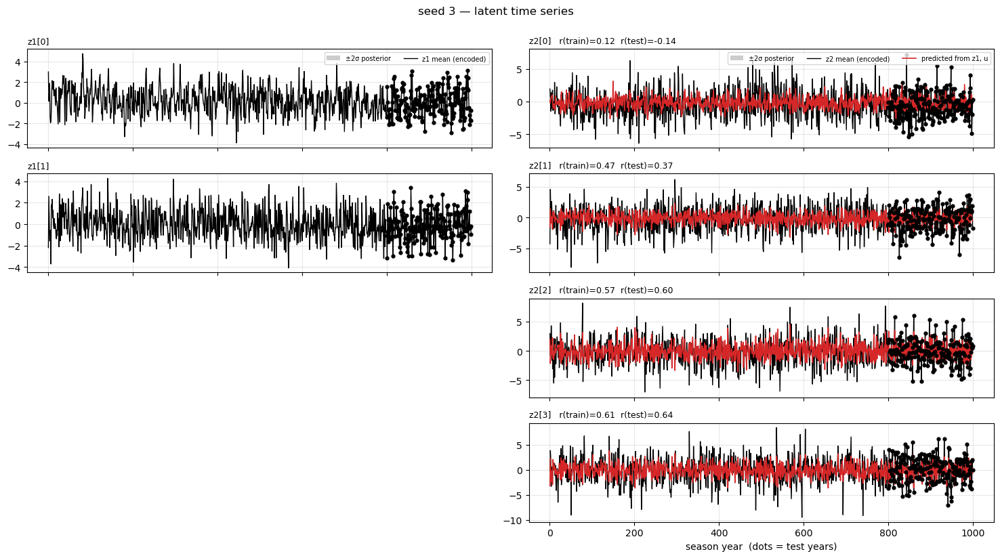

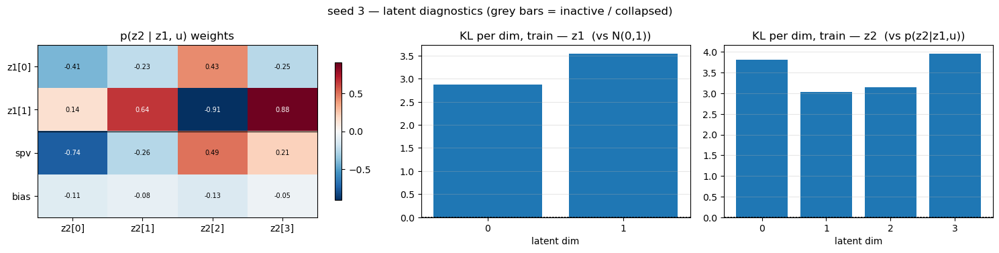

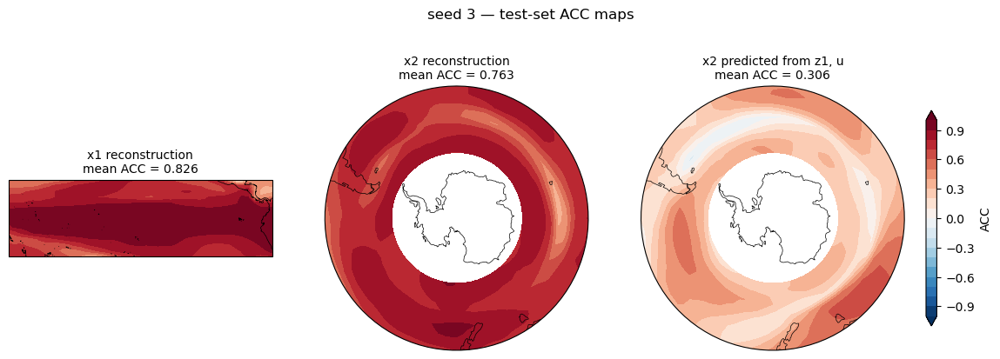

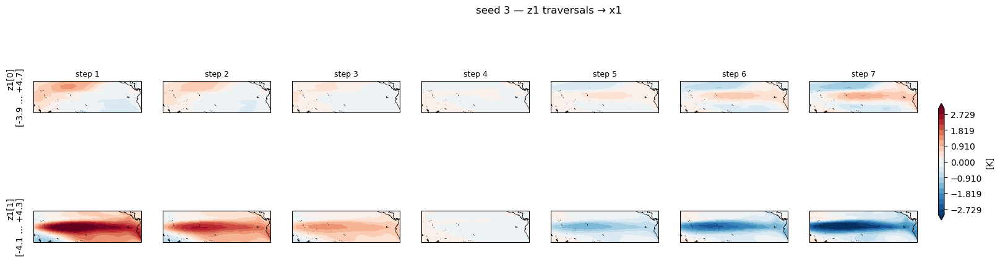

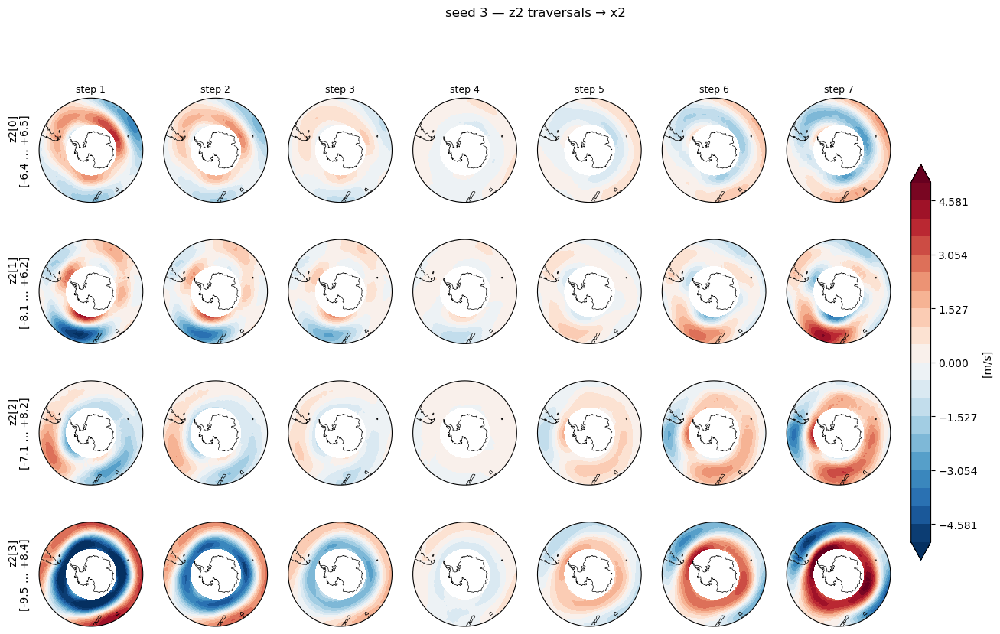

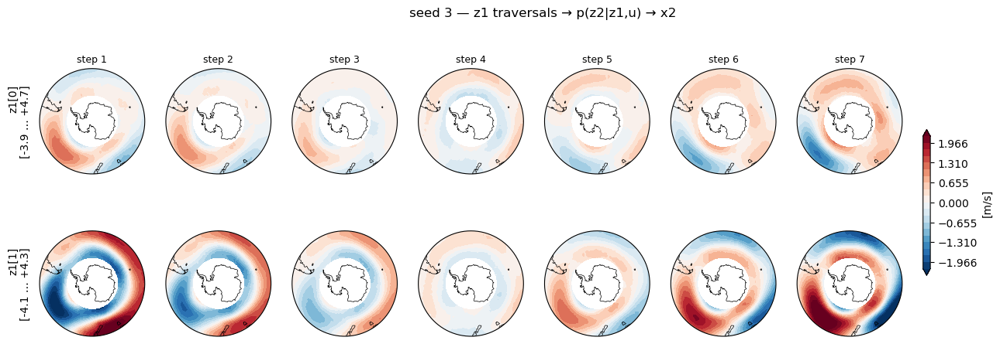

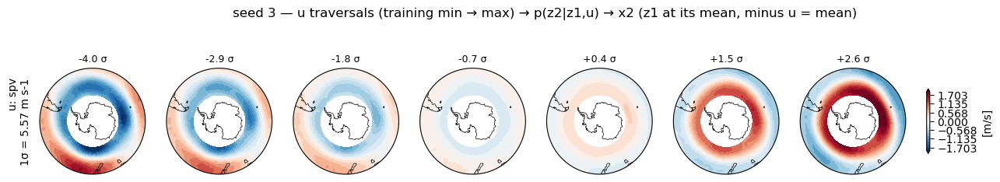


▶ training seed 4
  epoch    20  loss    912.50  val_loss    882.25  test ACC z1->x2 0.316  x2 rec 0.665
  epoch    40  loss    841.01  val_loss    813.05  test ACC z1->x2 0.320  x2 rec 0.711
  epoch    60  loss    821.87  val_loss    794.45  test ACC z1->x2 0.325  x2 rec 0.722
  epoch    80  loss    792.44  val_loss    776.44  test ACC z1->x2 0.318  x2 rec 0.748
  epoch   100  loss    764.10  val_loss    765.04  test ACC z1->x2 0.320  x2 rec 0.758

── seed 4  (6 s) ────────────────────────────────────────
                               train      test
total loss                   733.322   764.573
rec loss x1 (weighted)       193.635   196.460
rec loss x2 (weighted)       310.248   338.445
KL z1                          6.181     6.438
KL z2 | p(z2|z1,u)            13.914    13.274
pred loss x2 (weighted)      209.312   209.924
MSE x1 rec                     0.305     0.308
MSE x2 rec                     0.240     0.264
MSE x2 pred                    0.542     0.544
expl. var x1 rec 

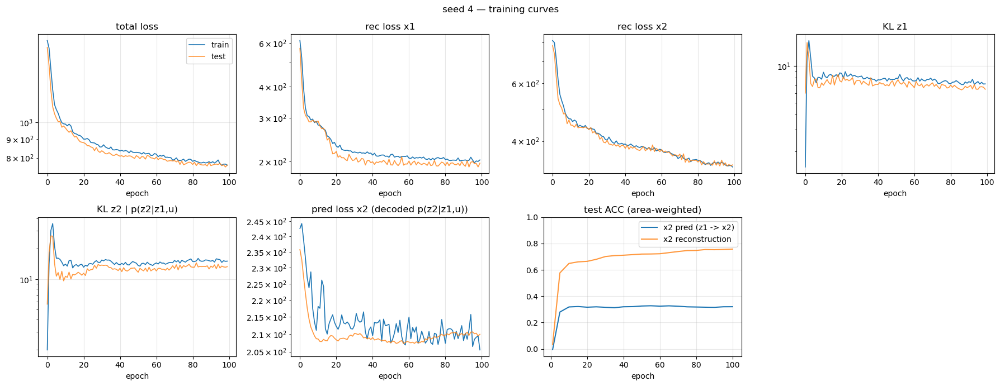

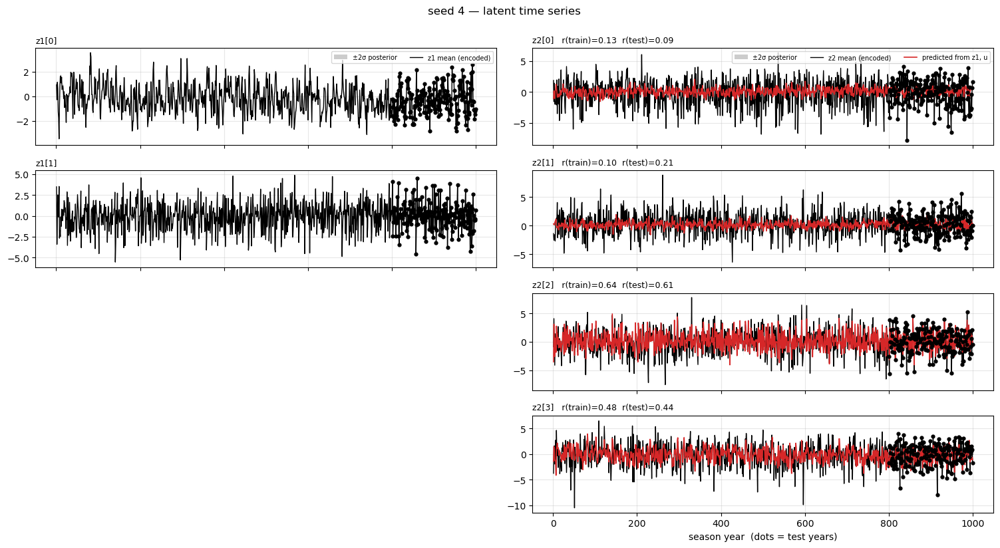

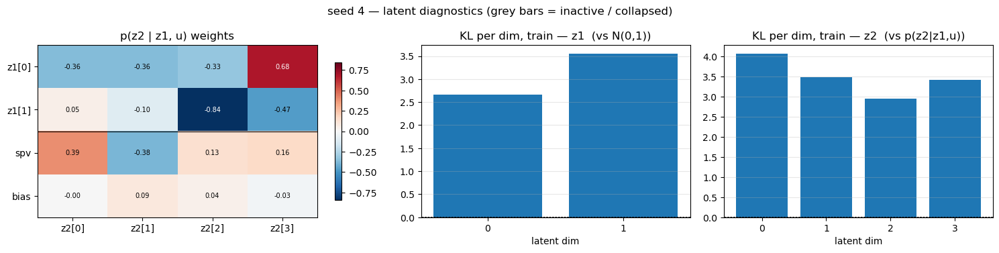

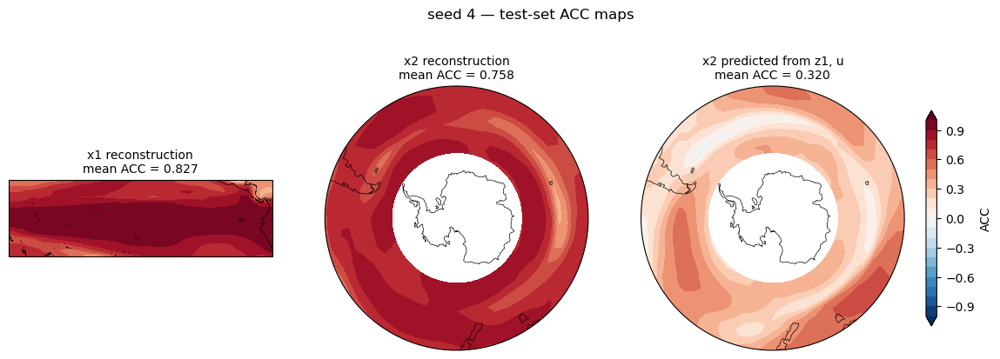

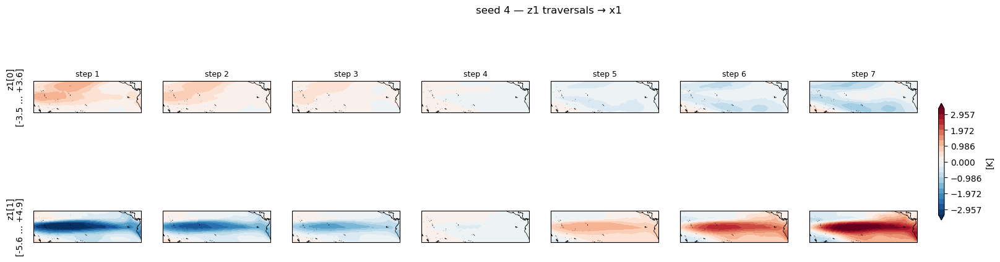

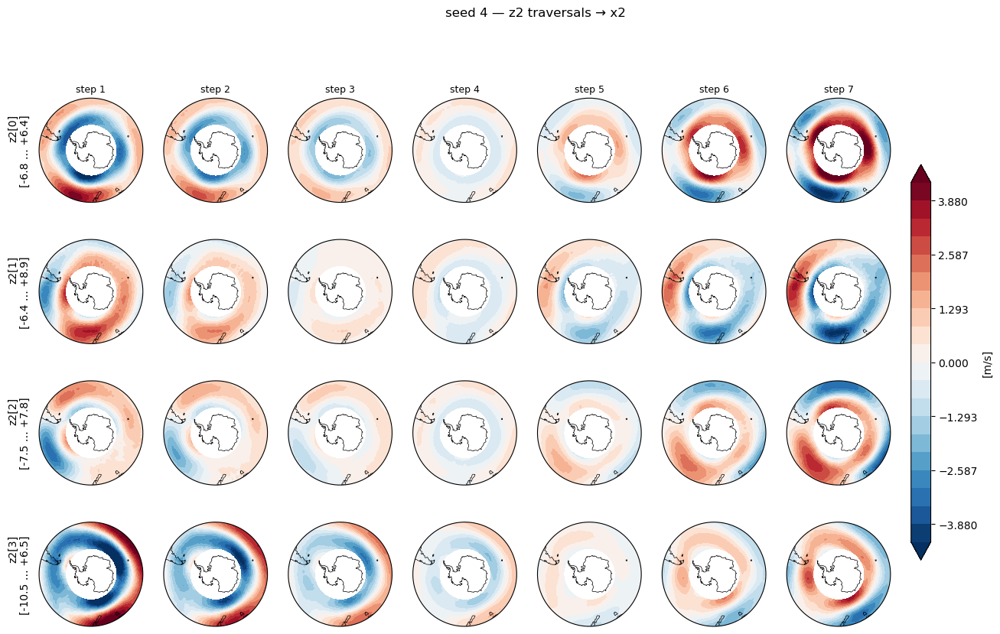

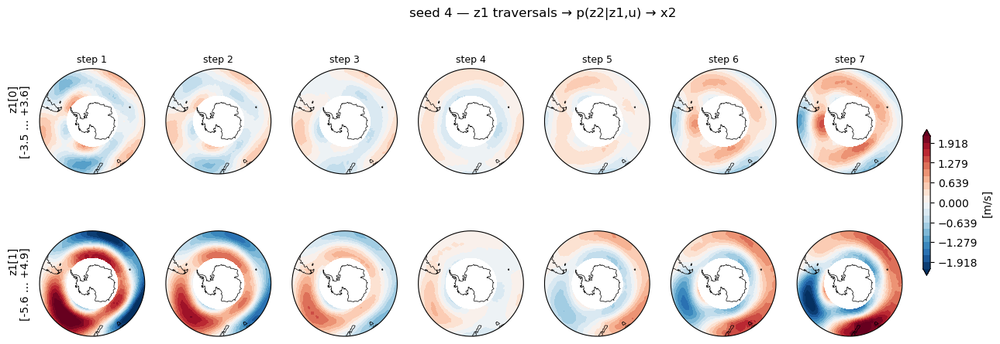

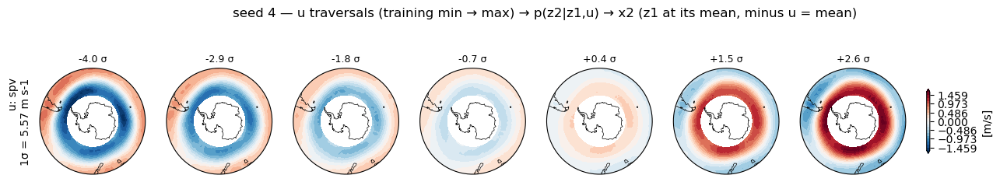


▶ training seed 5
  epoch    20  loss    911.66  val_loss    887.15  test ACC z1->x2 0.316  x2 rec 0.663
  epoch    40  loss    830.94  val_loss    791.81  test ACC z1->x2 0.335  x2 rec 0.728
  epoch    60  loss    780.51  val_loss    759.14  test ACC z1->x2 0.331  x2 rec 0.757
  epoch    80  loss    767.75  val_loss    750.89  test ACC z1->x2 0.334  x2 rec 0.761
  epoch   100  loss    766.68  val_loss    747.28  test ACC z1->x2 0.336  x2 rec 0.764

── seed 5  (5 s) ────────────────────────────────────────
                               train      test
total loss                   723.390   746.430
rec loss x1 (weighted)       192.632   196.044
rec loss x2 (weighted)       300.759   324.650
KL z1                          6.852     6.945
KL z2 | p(z2|z1,u)            13.629    13.021
pred loss x2 (weighted)      209.493   205.745
MSE x1 rec                     0.304     0.309
MSE x2 rec                     0.233     0.253
MSE x2 pred                    0.543     0.535
expl. var x1 rec 

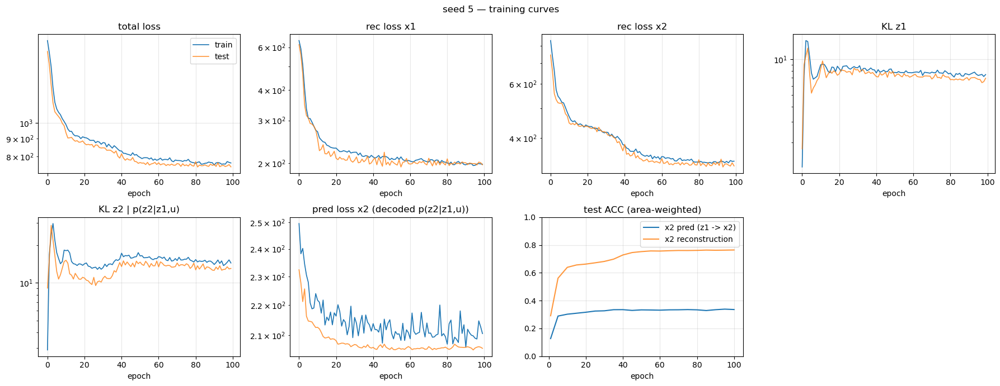

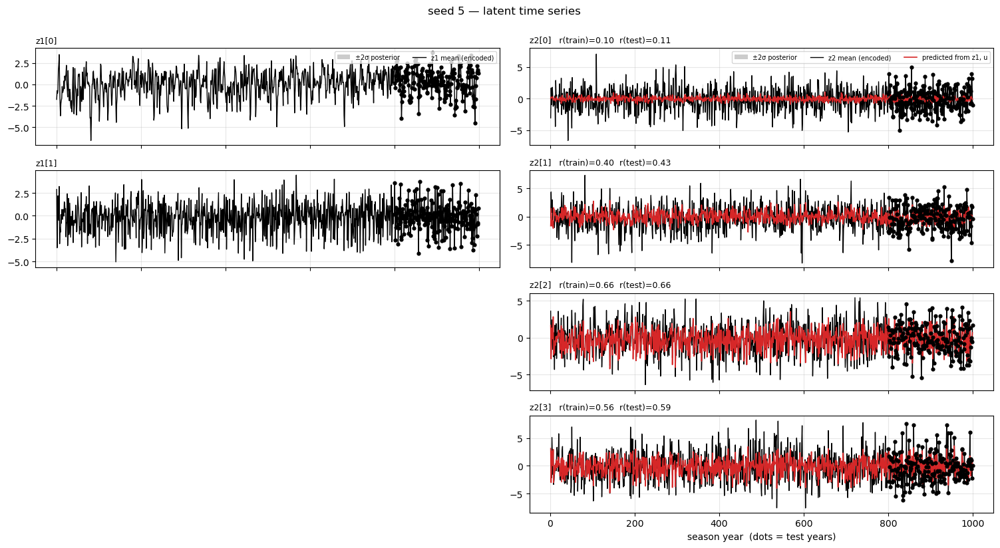

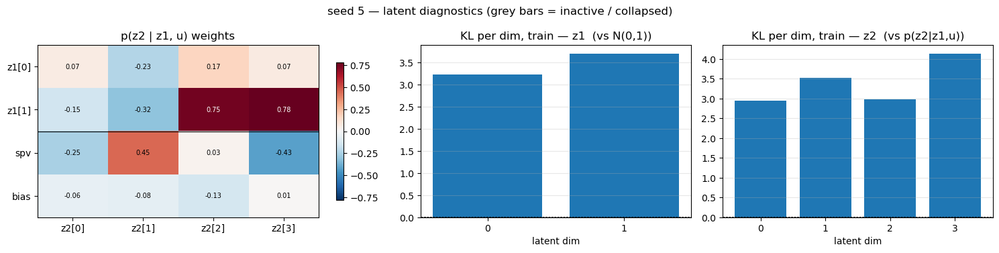

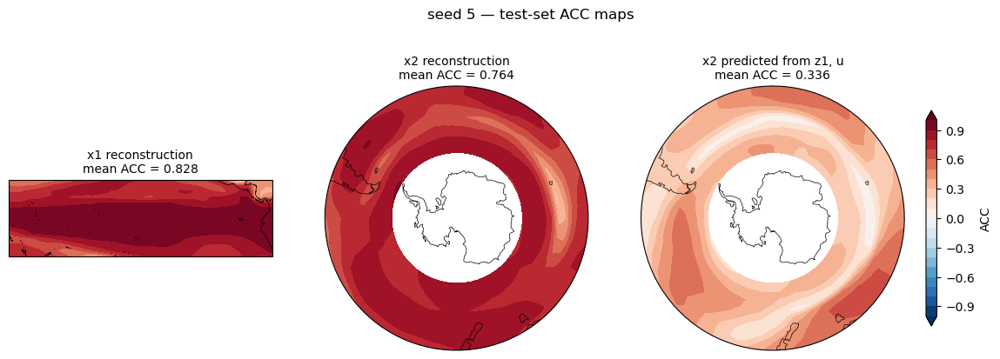

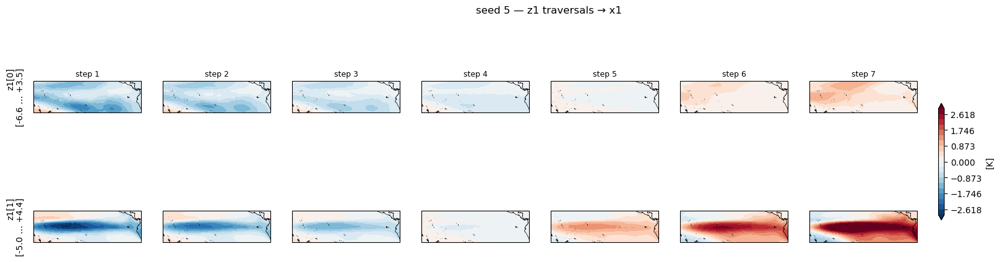

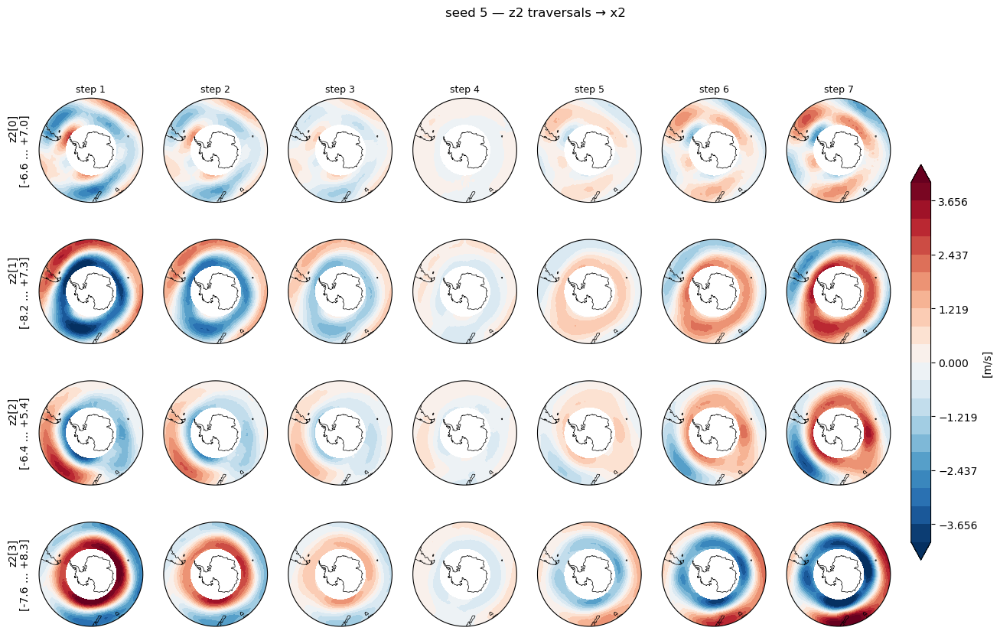

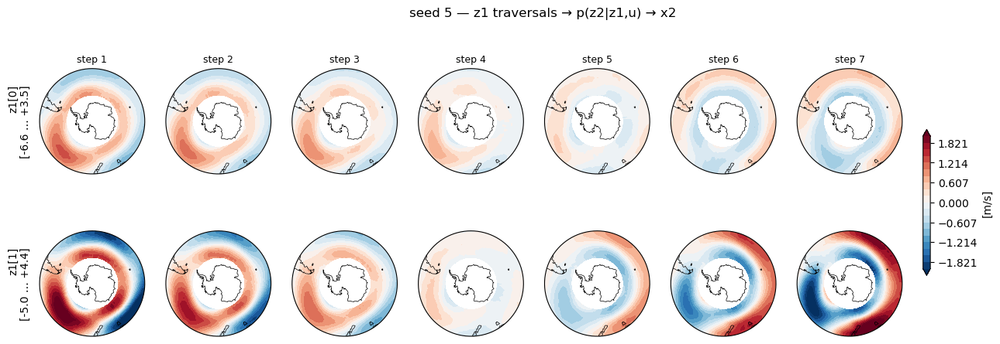

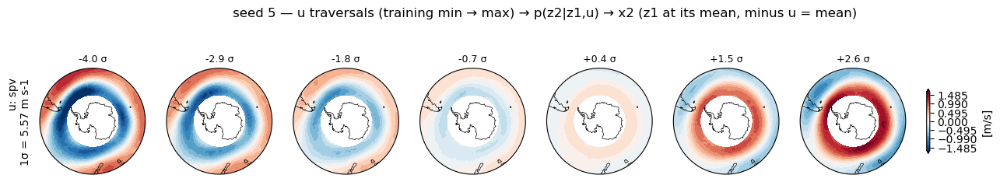


▶ training seed 6
  epoch    20  loss    945.43  val_loss    947.06  test ACC z1->x2 0.330  x2 rec 0.664
  epoch    40  loss    848.32  val_loss    831.32  test ACC z1->x2 0.325  x2 rec 0.715
  epoch    60  loss    811.47  val_loss    823.32  test ACC z1->x2 0.339  x2 rec 0.721
  epoch    80  loss    796.92  val_loss    804.41  test ACC z1->x2 0.329  x2 rec 0.738
  epoch   100  loss    768.47  val_loss    796.36  test ACC z1->x2 0.322  x2 rec 0.752

── seed 6  (5 s) ────────────────────────────────────────
                               train      test
total loss                   738.854   796.393
rec loss x1 (weighted)       216.143   218.492
rec loss x2 (weighted)       315.853   348.599
KL z1                          6.748     6.843
KL z2 | p(z2|z1,u)            13.674    13.695
pred loss x2 (weighted)      186.403   208.733
MSE x1 rec                     0.340     0.343
MSE x2 rec                     0.245     0.271
MSE x2 pred                    0.486     0.544
expl. var x1 rec 

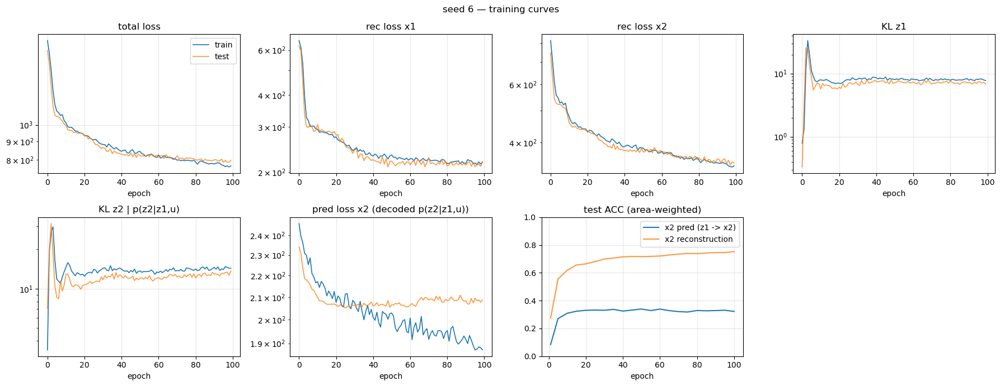

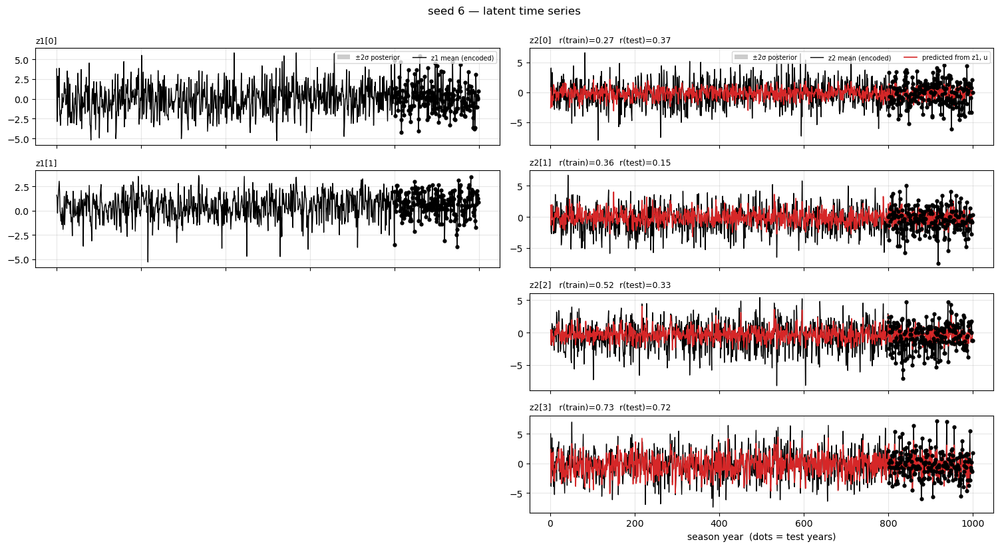

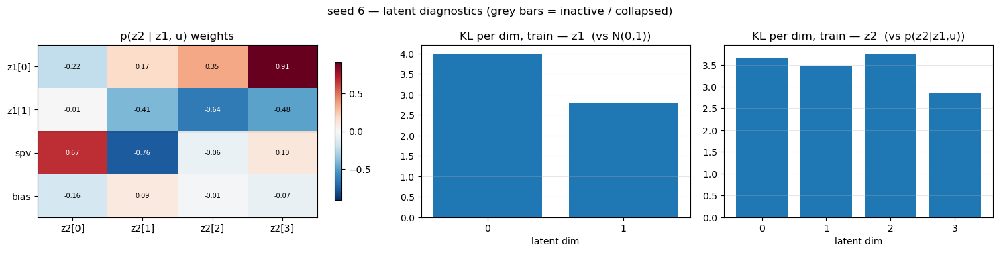

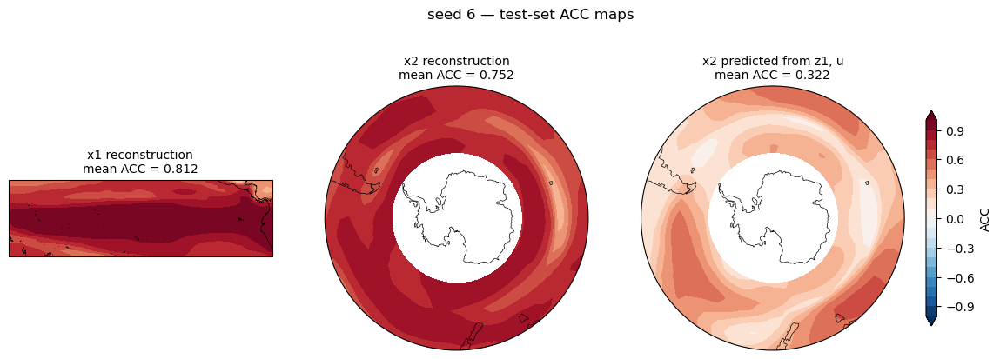

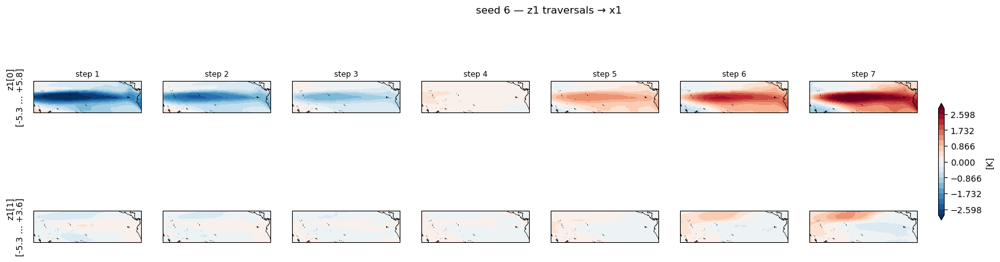

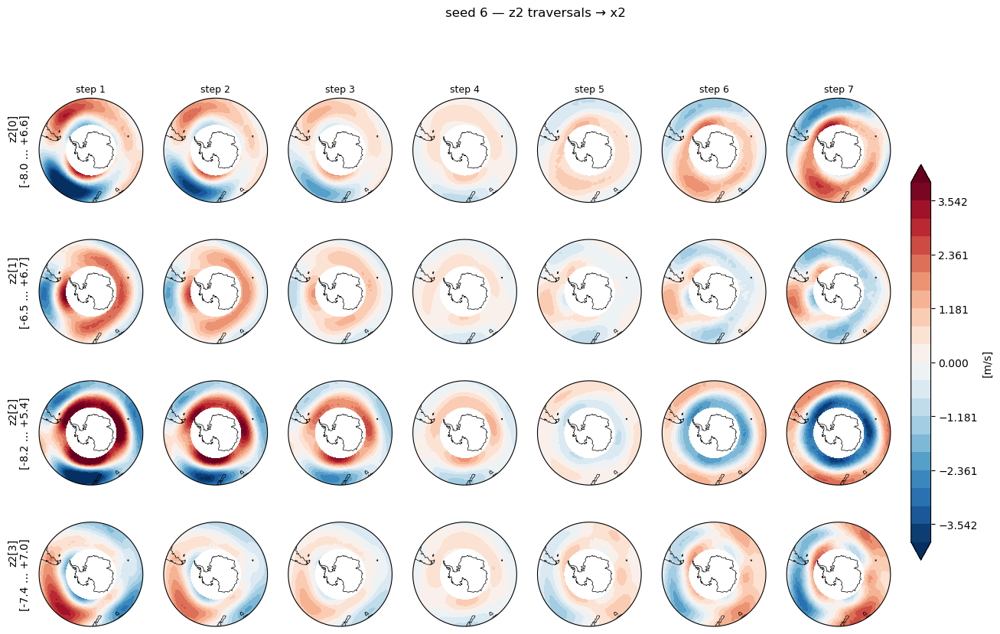

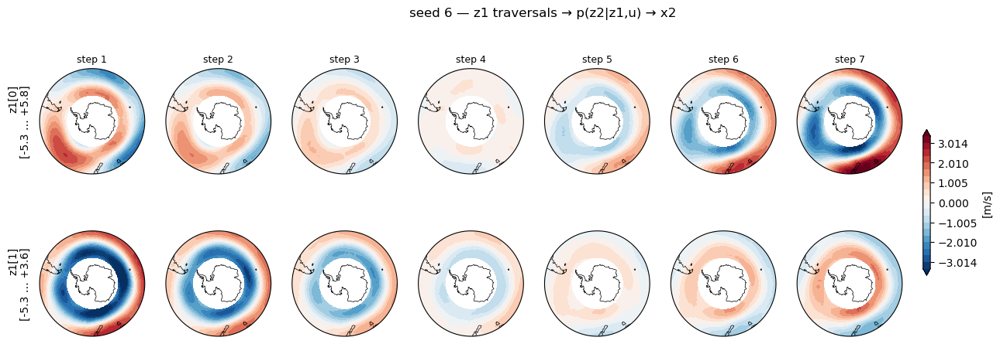

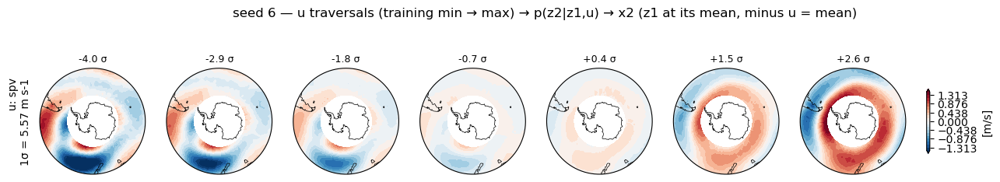


▶ training seed 7
  epoch    20  loss    949.82  val_loss    957.70  test ACC z1->x2 0.320  x2 rec 0.660
  epoch    40  loss    849.85  val_loss    834.54  test ACC z1->x2 0.328  x2 rec 0.717
  epoch    60  loss    790.12  val_loss    781.59  test ACC z1->x2 0.340  x2 rec 0.752
  epoch    80  loss    770.79  val_loss    769.68  test ACC z1->x2 0.343  x2 rec 0.760
  epoch   100  loss    769.10  val_loss    767.67  test ACC z1->x2 0.332  x2 rec 0.763

── seed 7  (5 s) ────────────────────────────────────────
                               train      test
total loss                   719.198   767.475
rec loss x1 (weighted)       204.321   202.556
rec loss x2 (weighted)       309.994   334.921
KL z1                          7.698     7.701
KL z2 | p(z2|z1,u)            13.079    13.278
pred loss x2 (weighted)      184.062   208.974
MSE x1 rec                     0.322     0.319
MSE x2 rec                     0.239     0.261
MSE x2 pred                    0.483     0.542
expl. var x1 rec 

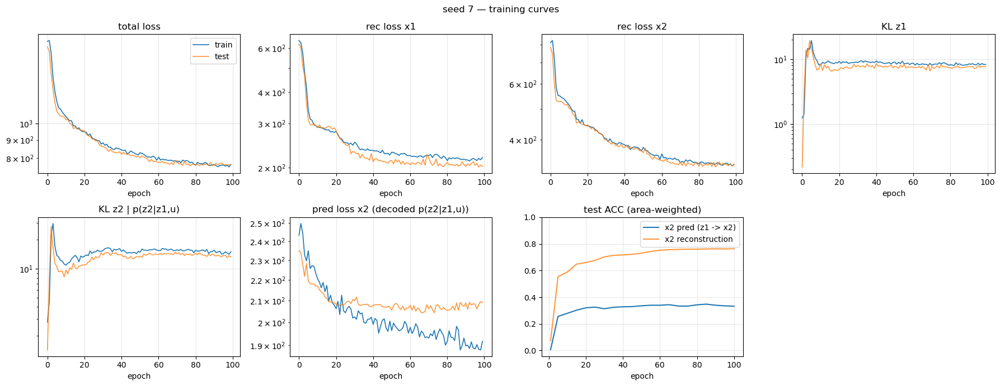

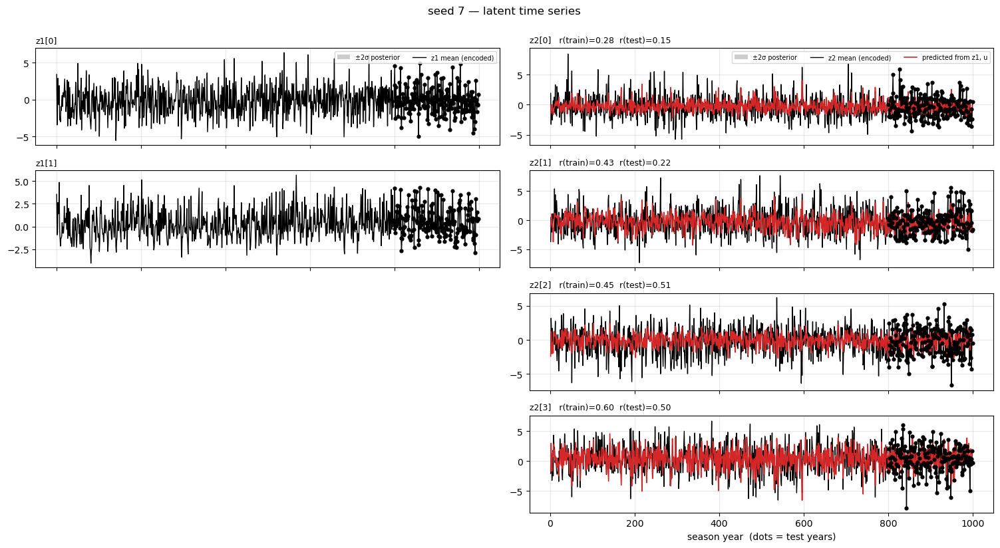

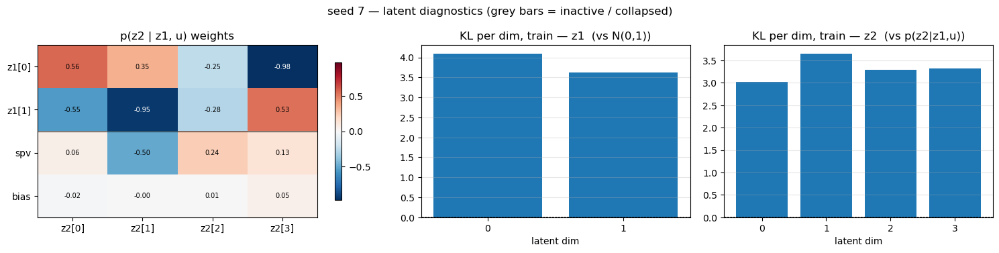

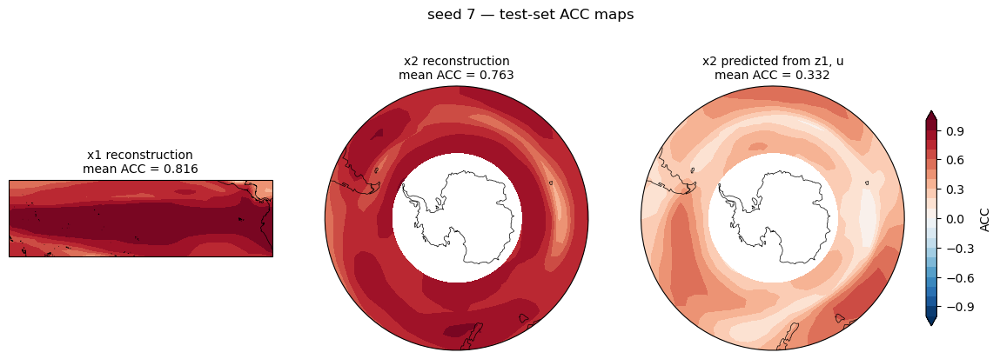

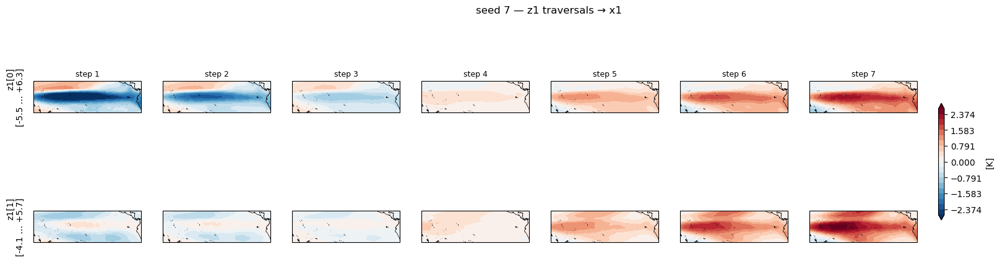

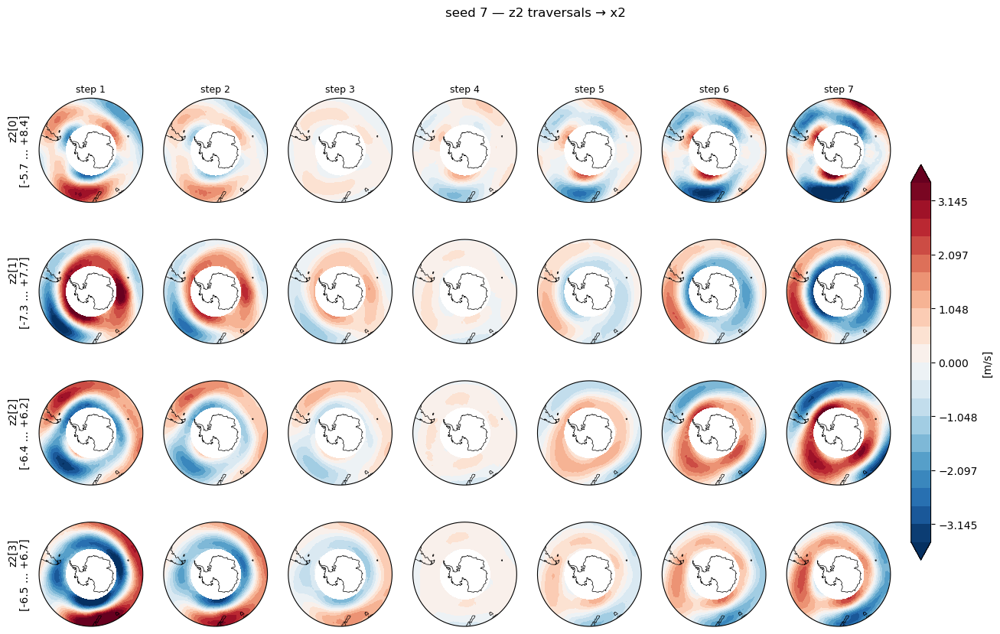

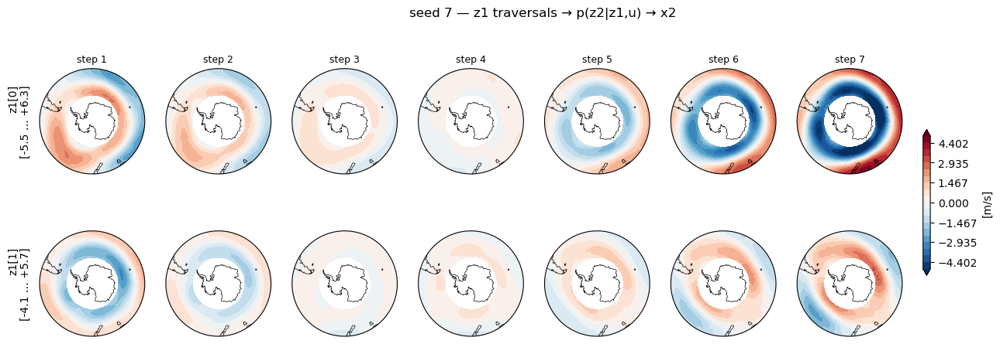

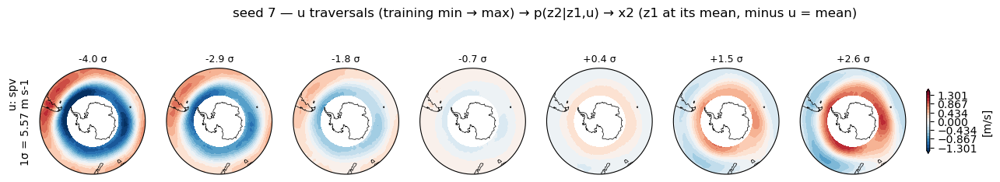


▶ training seed 8
  epoch    20  loss    941.83  val_loss    926.36  test ACC z1->x2 0.332  x2 rec 0.678
  epoch    40  loss    855.24  val_loss    834.82  test ACC z1->x2 0.330  x2 rec 0.719
  epoch    60  loss    808.45  val_loss    785.57  test ACC z1->x2 0.333  x2 rec 0.749
  epoch    80  loss    793.26  val_loss    763.01  test ACC z1->x2 0.328  x2 rec 0.754
  epoch   100  loss    766.65  val_loss    761.37  test ACC z1->x2 0.332  x2 rec 0.756

── seed 8  (5 s) ────────────────────────────────────────
                               train      test
total loss                   731.510   759.955
rec loss x1 (weighted)       194.598   195.692
rec loss x2 (weighted)       310.449   338.139
KL z1                          6.786     6.871
KL z2 | p(z2|z1,u)            13.893    13.028
pred loss x2 (weighted)      205.746   206.187
MSE x1 rec                     0.308     0.308
MSE x2 rec                     0.240     0.265
MSE x2 pred                    0.535     0.537
expl. var x1 rec 

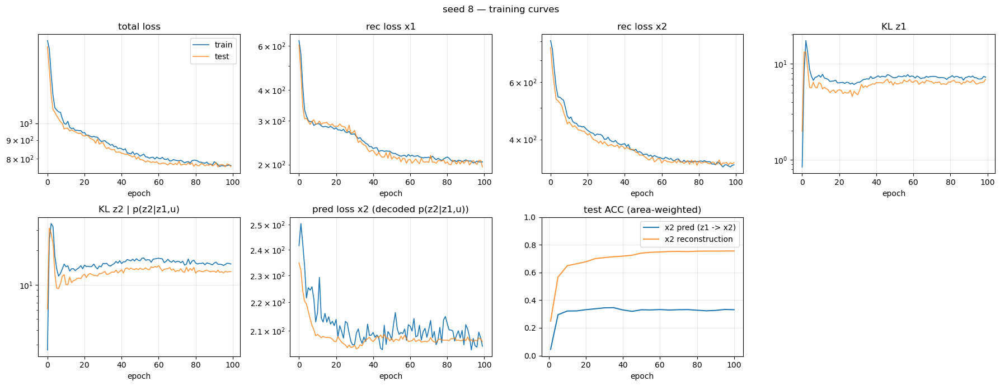

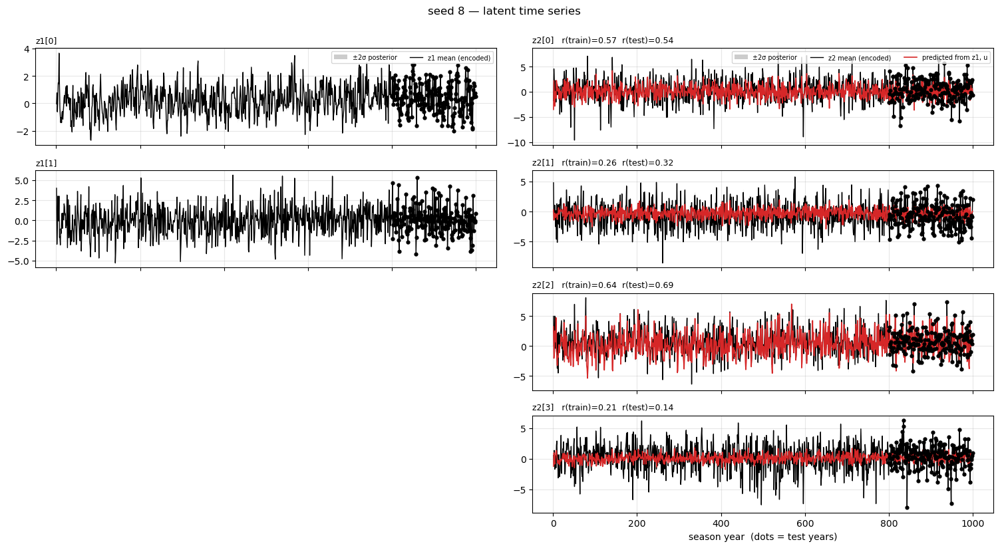

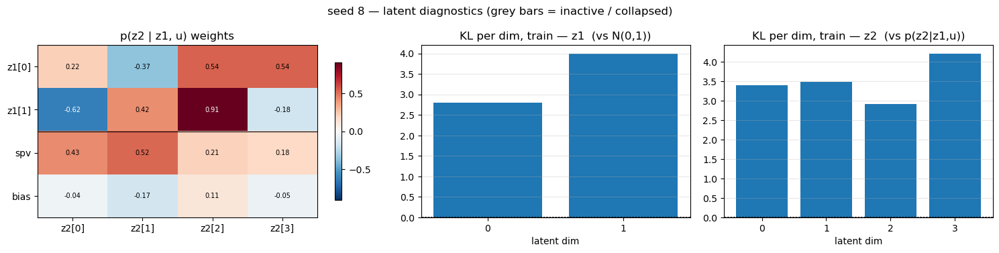

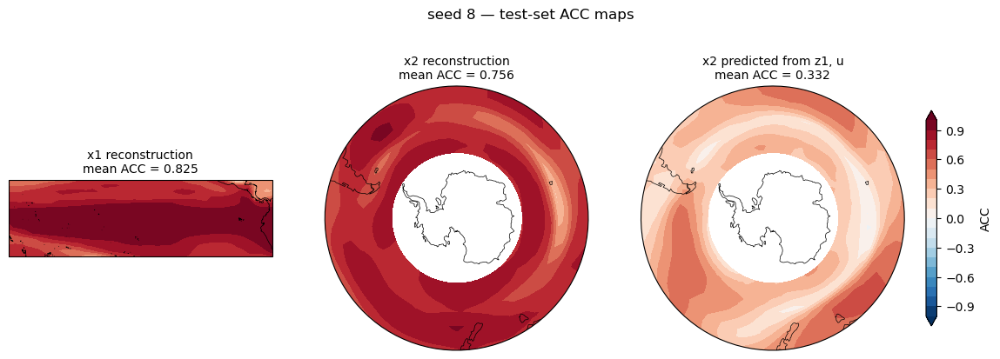

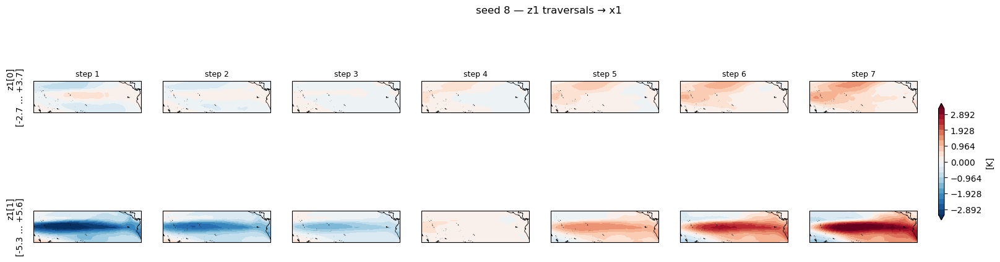

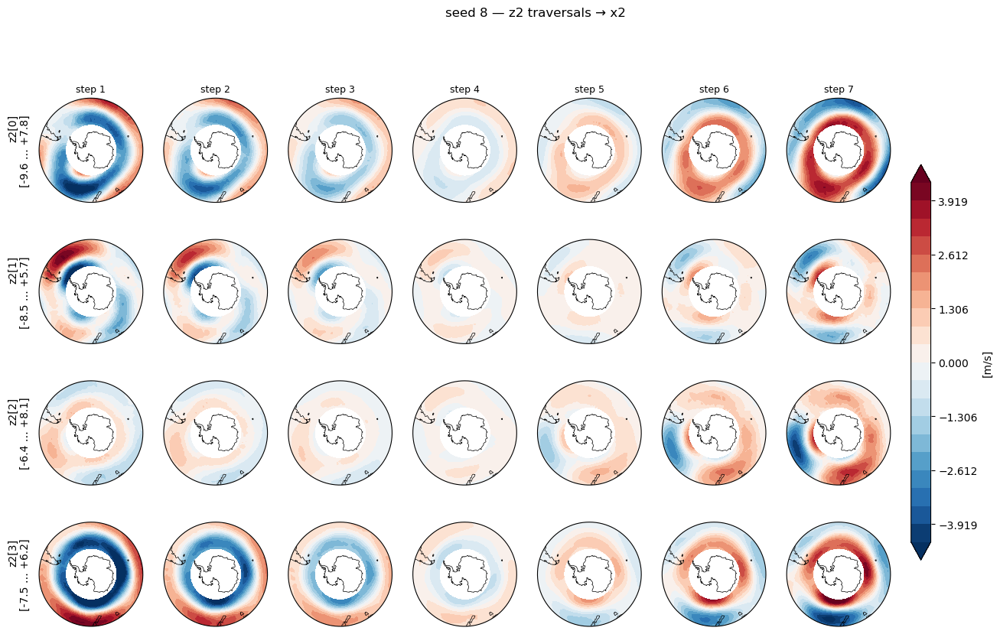

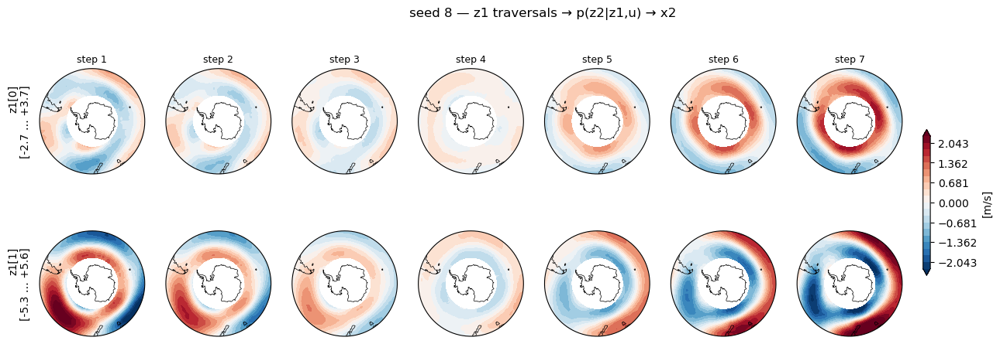

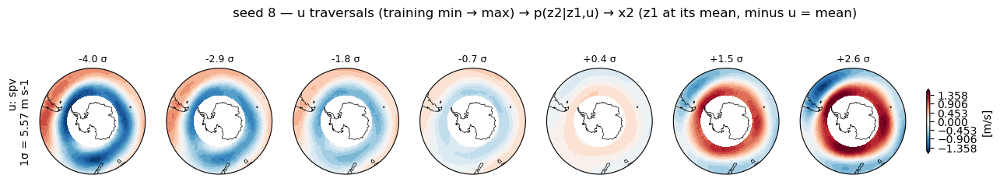


▶ training seed 9
  epoch    20  loss    930.37  val_loss    926.57  test ACC z1->x2 0.331  x2 rec 0.660
  epoch    40  loss    853.92  val_loss    828.30  test ACC z1->x2 0.288  x2 rec 0.717
  epoch    60  loss    815.65  val_loss    813.64  test ACC z1->x2 0.298  x2 rec 0.727
  epoch    80  loss    785.88  val_loss    771.63  test ACC z1->x2 0.315  x2 rec 0.759
  epoch   100  loss    759.63  val_loss    773.73  test ACC z1->x2 0.317  x2 rec 0.758

── seed 9  (5 s) ────────────────────────────────────────
                               train      test
total loss                   725.617   772.339
rec loss x1 (weighted)       212.522   212.951
rec loss x2 (weighted)       303.294   331.855
KL z1                          6.628     6.689
KL z2 | p(z2|z1,u)            13.056    13.205
pred loss x2 (weighted)      190.072   207.593
MSE x1 rec                     0.334     0.335
MSE x2 rec                     0.236     0.260
MSE x2 pred                    0.495     0.544
expl. var x1 rec 

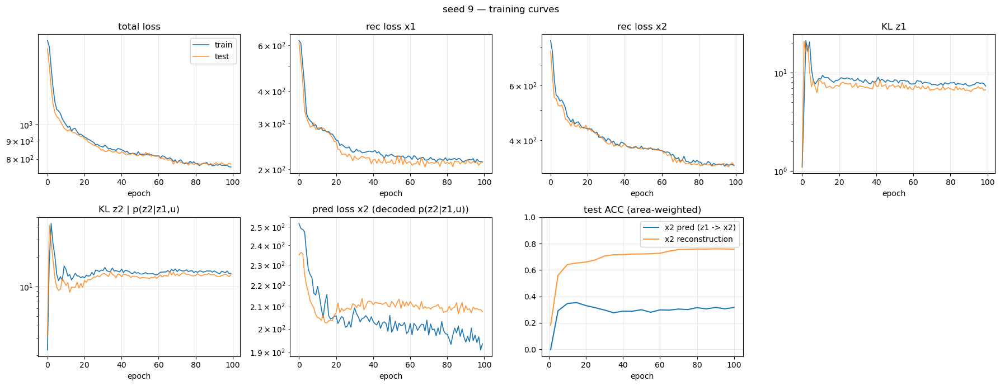

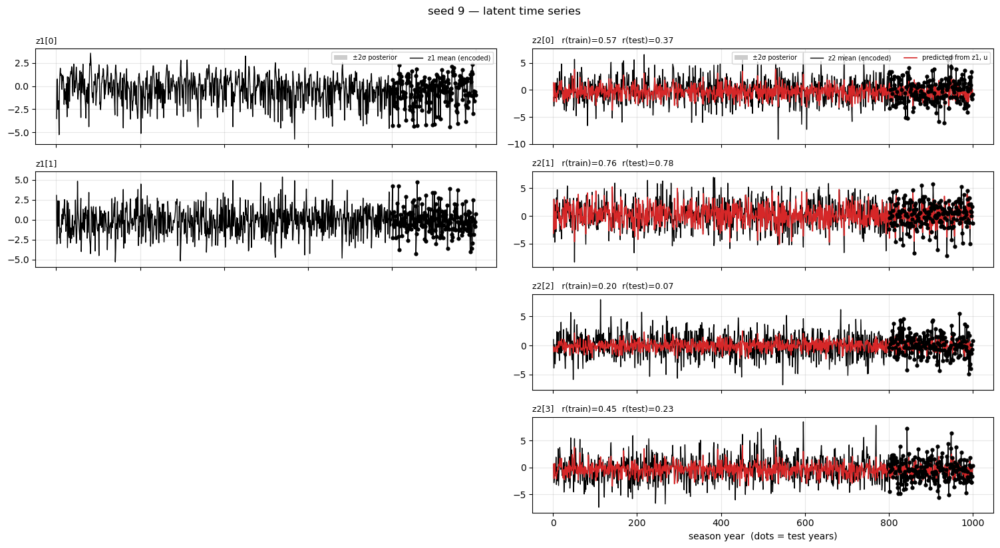

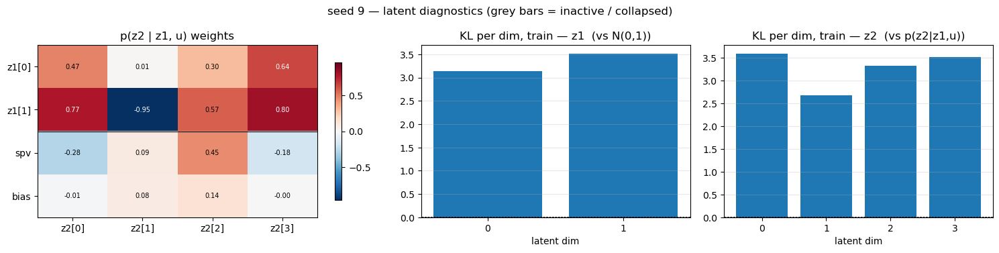

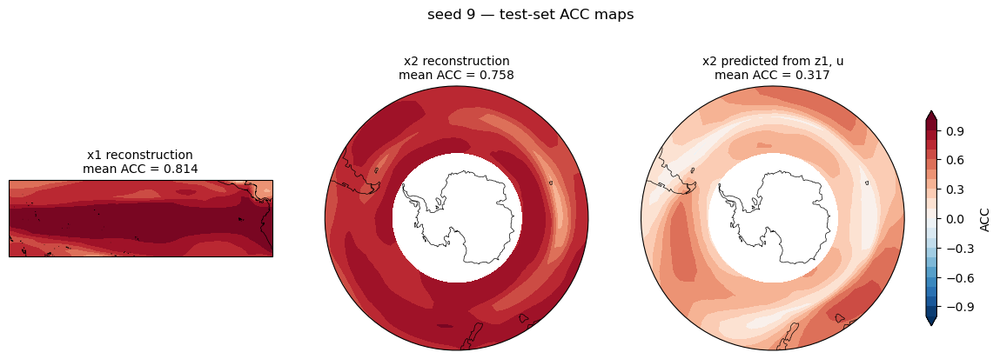

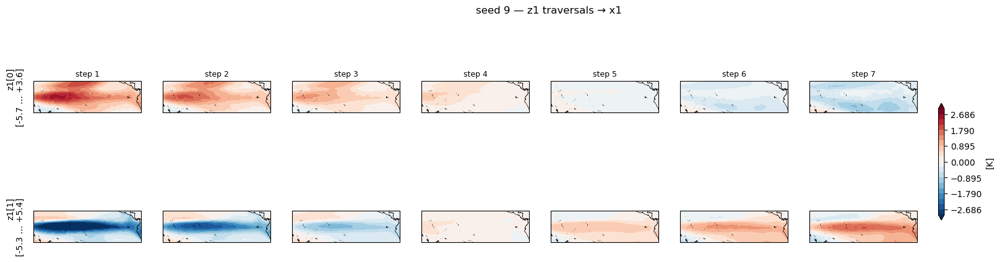

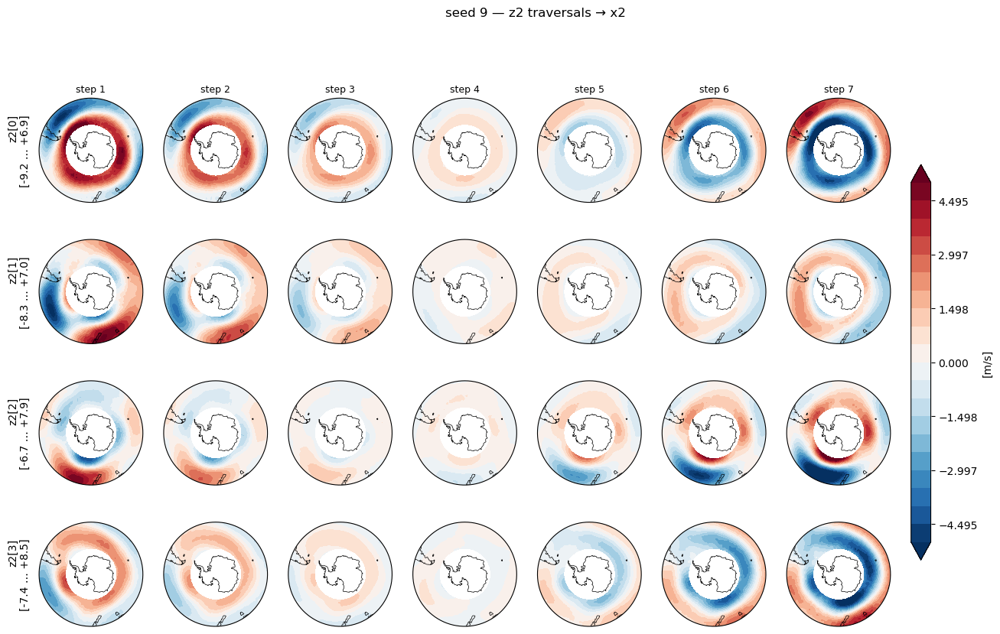

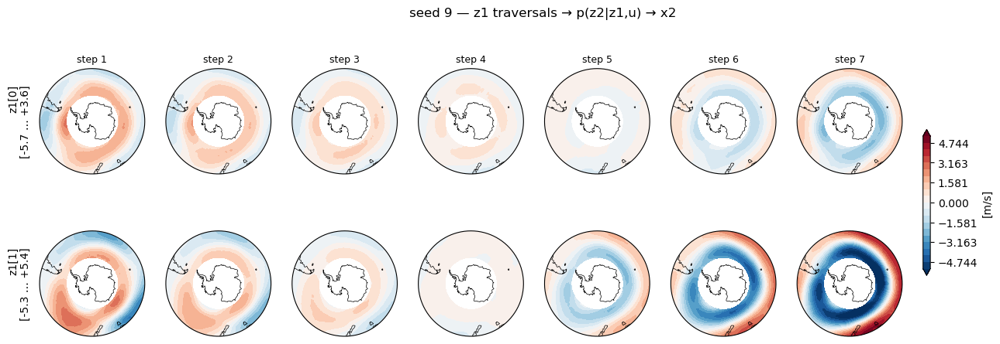

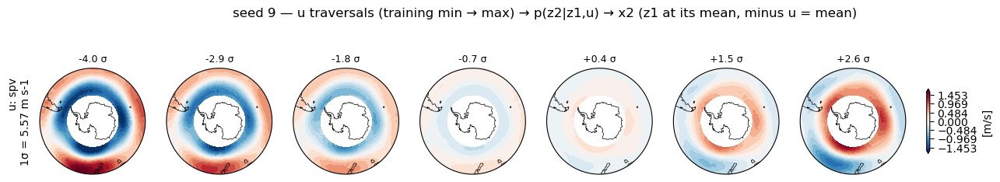

In [9]:
seeds_ls = list(range(10))

CFG = tr.make_config(dict(          # keys not given here take their value from tr.DEFAULT_CFG
    seeds=seeds_ls,

    # architecture
    latent_dim_z1=2,
    latent_dim_z2=4,
    hidden_dims=(128, 64, 32),      # encoder widths, input side first (decoder mirrors it)
    activation='relu',
    dropout_rate=0.3,

    # loss
    reconstruction_loss_factors=[1.0, 1.0],
    kl_loss_factors=[1.0, 1.0],
    prediction_loss_factor=0.3,     # MSE(x2, decode(z1, p(z2|z1,u))); 0 = off
    regularization_term=0.01,       # L1 on z1 -> z2 weights
    covariate_reg=0.0,              # L1 on u -> z2 weights

    # optimisation
    learning_rate=1e-3,
    epochs=100,
    batch_size=128,
    deterministic_ops=False,

    # monitoring / output
    print_every=20,
    acc_every=5,
    out_dir='runs/vae_seeds',
    show_figs_for_seeds=seeds_ls,   # displayed in the notebook; all seeds are saved to disk

    # plotting
    traversal_n=7,
    traversal_relative=False,
    response_sweep='minmax', # minmax,  # 'std' = ±1σ, 'minmax' = min/max of the training data
    plot_physical_units=True,       # maps in K and m/s (False: standardised units)
    x1_unit='[K]',
    x2_unit='[m/s]',
    x1_projection=ccrs.PlateCarree(central_longitude=180),   # None = choose from the box
    x2_projection=ccrs.SouthPolarStereo(),
))

results = tr.run_all_seeds(CFG, data)

### Across-seed summary


Per-seed metrics (full table in metrics_per_seed.csv):
      test_loss_total  test_loss_rec_x1  test_loss_rec_x2  test_loss_kl_z1  test_loss_kl_z2  test_loss_pred_x2  test_acc_x1_rec  test_acc_x2_rec  test_acc_x2_pred  test_pcorr_x2_pred  \
seed                                                                                                                                                                                     
0             887.392           285.201           375.501            4.399           12.830            209.435            0.728            0.722             0.316               0.276   
1             902.448           286.943           392.799            3.321           11.510            207.845            0.737            0.706             0.318               0.280   
2             878.464           278.963           377.959            3.569           11.660            206.290            0.738            0.718             0.336               0.296   
3             

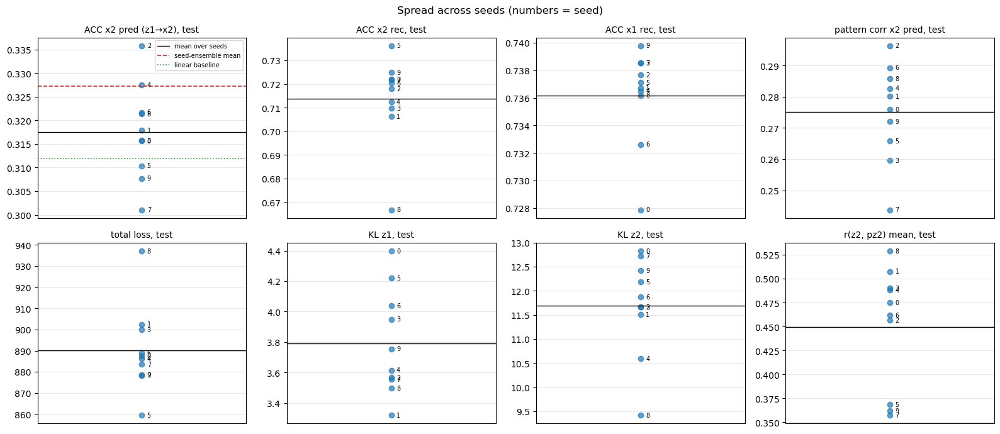

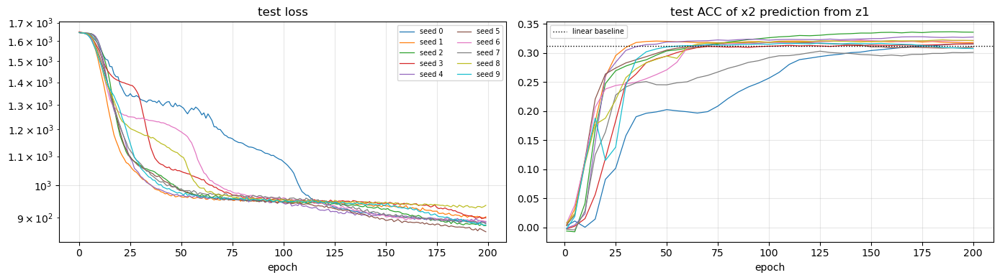

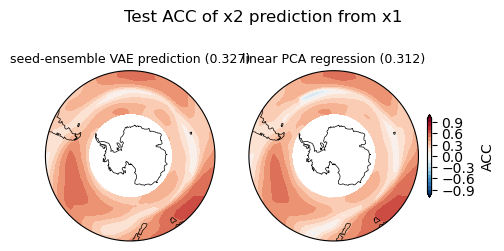

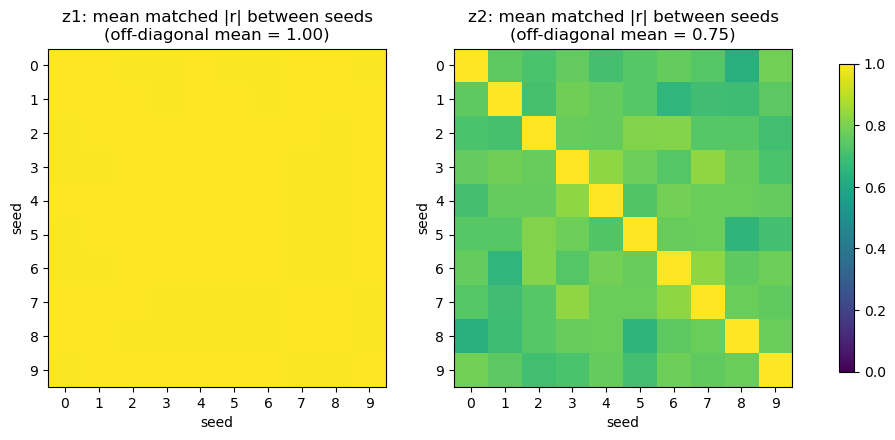

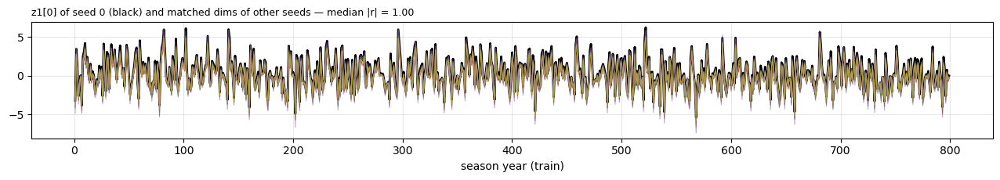

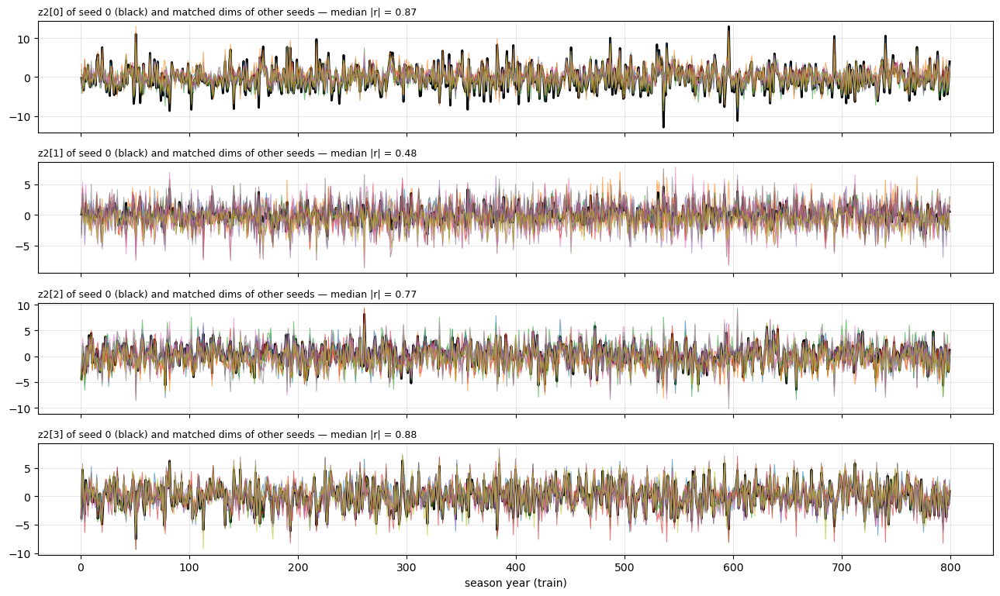

In [5]:
df = tr.metrics_table(results, CFG)
ref = tr.baseline_and_ensemble(results, df, CFG, data)

vis.plot_summary_metrics(df, ref, CFG)
vis.plot_summary_training(results, ref, CFG)
vis.plot_summary_acc_maps(ref, CFG, data)

# latent reproducibility across seeds
vis.plot_latent_stability(results, CFG)
vis.plot_aligned_latents(results, CFG, data)

### Seed-mean z1 → x2 response

Each z1 dim (matched and sign-aligned to the first seed) is swept over ±2 std, mapped through p(z2|z1,u) and
decoded to x2; maps show the mean over seeds, stippled where ≥ 80 % of seeds agree on the sign.

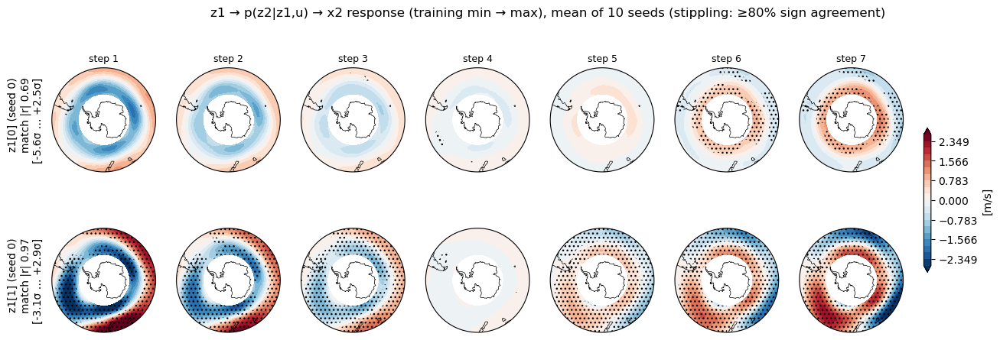

median matched |r| per z1 dim (vs seed 0 ): [0.69 0.97]


In [10]:
#resp = tr.seed_mean_z1_response(results, CFG, data, sigma=2.0)
resp = tr.seed_mean_z1_response(results, CFG, data, sweep='minmax', sigma=2.0)   # or sweep='minmax'
vis.plot_seed_mean_z1_response(resp, CFG, data, agree_threshold=0.8,
                               filename='summary_traversal_z1_to_x2_seedmean_latent1.png')
print('median matched |r| per z1 dim (vs seed', resp['ref_seed'], '):',
      np.round(np.median(resp['match_r'][1:], 0), 2))

### Seed-mean u → x2 response

Each covariate is swept over its training mean ± 2 std (z1 held at its training mean, other covariates at their
mean), mapped through p(z2|z1,u) and decoded to x2, relative to u = mean. u is an input, so no matching across
seeds is needed. Per-seed versions are saved as `seed_XXX/traversal_u_to_x2.png` during training.

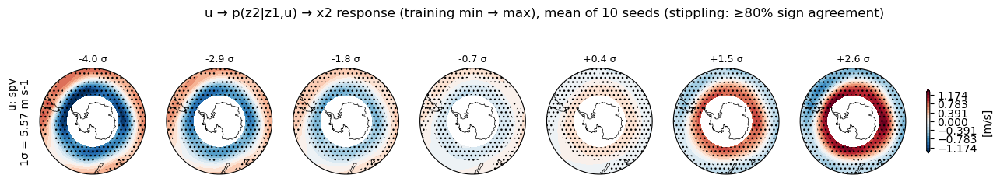

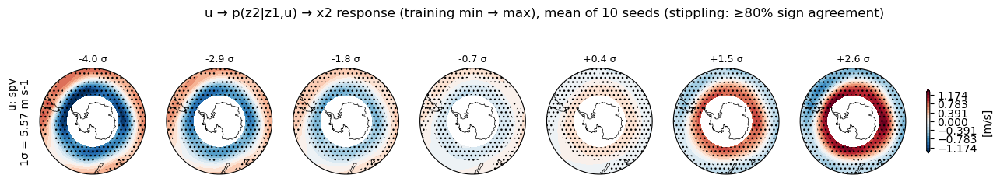

In [11]:
resp_u = tr.covariate_response(results, CFG, data, sigma=2.0)
vis.plot_covariate_response(resp_u, CFG, data, agree_threshold=0.8)

# a single seed, e.g. seed 0:
# enc, dec, pm = tr.load_seed_models(0, CFG, data, results)
# vis.plot_traversal_u_to_x2(dec, pm, results[0]['enc_tr'], 0, CFG, data); plt.show()